# vizlab — every visualization in one notebook

`vizlab` is the visualization layer of **luxonis-ml**. It turns Luxonis Data
Format (LDF) annotations into finished pictures — bounding boxes, instance and
semantic masks, keypoints, dense arrays, classifications — with a shared
palette, collision-aware label placement, and a look that stays consistent from
a quick `data inspect` window to a figure in a paper.

This notebook is the tour. It shows

1. **[LDF in, picture out](#1)** — every annotation type LDF can carry, as the
   data that produces it,
2. **[the annotation types up close](#2)** — the same labels built by hand,
3. **[dense fields and arrays](#3)** — heatmaps, depth, flow, normals, scores,
4. **[appearance](#4)** — themes, palettes, per-annotation styles, inline markup,
5. **[composition](#5)** — blending, stacking, grids, side panels,
6. **[comparing predictions](#6)** — verdict colouring and confusion matrices,
7. **[getting it out](#7)** — PNG, SVG, interactive HTML, video,
8. **[the interactive viewer](#8)** — paging a dataset inside this notebook.

Every frame here is painted with numpy, so **no dataset download is needed** and
every cell runs offline.

```bash
pip install "luxonis-ml[viz]"       # everything except the last two sections
pip install "luxonis-ml[data]"      # + the LuxonisDataset round-trip (§1.9)
pip install "luxonis-ml[notebook]"  # + the interactive viewer (§8)
```

Run it top to bottom.

## Setup

Two things worth knowing before the first picture.

**A scene displays itself.** `Image` and the composites built from it implement
`_repr_png_`, so leaving one as the last expression of a cell shows it — no
`display()`, no Matplotlib. Nothing is drawn until then: `Image.add` only
records annotations, and the whole scene is rasterised in one pass at render
time, which is what lets vizlab lay every label out together.

**Coordinates are normalized.** Every position is a fraction of the image in
`[0, 1]` — the LDF convention. A box is `x, y` (top-left) plus `w, h`; a
keypoint is `(x, y, visibility)` with COCO visibility `0`/`1`/`2`.

In [2]:
import numpy as np

from luxonis_ml.ldf import DatasetRecord, Detection
from luxonis_ml.vizlab import (
    DARK_THEME,
    LIGHT_THEME,
    ArrayImage,
    BBox,
    Caption,
    ClassDistribution,
    Classification,
    Color,
    ColorBar,
    ComparisonReport,
    Corner,
    FlowField,
    FlowWheel,
    Gradient,
    Heatmap,
    Image,
    InfoCard,
    Keypoints,
    LabelPlacement,
    Legend,
    Mask,
    NormalMap,
    Palette,
    RenderOptions,
    ScalarField,
    SegmentationScores,
    SemanticMask,
    Style,
    Tooltip,
    blend,
    combine,
    compare,
    confusion_matrix_figure,
    escape,
    grid,
    hstack,
    match_detections,
    save_video,
    visualize_record,
    vstack,
)

W, H = 340, 250  # the size of a standard gallery cell below

### The synthetic imagery

Not vizlab — just numpy painting stand-ins for real data, so the notebook needs
no assets. `street()` fakes a driving frame, `ramp()` a plain gradient backdrop,
and the rest are the dense fields used in §3. Skip the cell; nothing below
depends on how it works.

In [3]:
def ramp(width: int = W, height: int = H, *, hue: float = 0.58) -> np.ndarray:
    """A smooth diagonal gradient — a neutral backdrop for annotations."""
    ys = np.linspace(0.0, 1.0, height)[:, None]
    xs = np.linspace(0.0, 1.0, width)[None, :]
    base = 30 + (xs + ys) / 2.0 * 70
    rgb = np.stack(
        [base * (0.7 + 0.3 * hue), base * 0.9, base * (0.9 + 0.4 * (1 - hue))],
        axis=-1,
    )
    return np.clip(rgb, 0, 255).astype(np.uint8)


def street(width: int = 640, height: int = 400) -> np.ndarray:
    """A believable street frame: sky, skyline, asphalt, receding lane."""
    img = np.zeros((height, width, 3), dtype=np.float64)
    horizon = int(height * 0.5)

    fade = np.linspace(0.0, 1.0, horizon)[:, None]
    sky = np.array([96, 132, 194]) * (1 - fade) + np.array([206, 214, 224]) * fade
    img[:horizon] = sky[:, None, :]

    fade = np.linspace(0.0, 1.0, height - horizon)[:, None]
    road = np.array([68, 70, 78]) * (1 - fade) + np.array([98, 100, 108]) * fade
    img[horizon:] = road[:, None, :]

    band = int(height * 0.16)
    for x0, wf, hf, shade in [
        (0.00, 0.12, 0.70, 58), (0.12, 0.09, 0.48, 66),
        (0.21, 0.10, 0.88, 50), (0.31, 0.07, 0.42, 72),
        (0.56, 0.09, 0.58, 60), (0.65, 0.12, 0.92, 48),
        (0.77, 0.08, 0.52, 68), (0.85, 0.15, 0.74, 54),
    ]:
        x_from, x_to = int(x0 * width), int((x0 + wf) * width)
        img[int(horizon - hf * band) : horizon, x_from:x_to] = [
            shade, shade + 6, shade + 18
        ]

    centre = width // 2
    for y in range(horizon + 6, height, 26):
        t = (y - horizon) / (height - horizon)
        half = max(1, int(2 + t * 6))
        img[y : y + int(6 + t * 16), centre - half : centre + half] = [
            212, 206, 178
        ]
    return np.clip(img, 0, 255).astype(np.uint8)


def blobs(width: int, height: int, centres) -> np.ndarray:
    """A sum of Gaussian bumps — a stand-in for a saliency map."""
    ys = np.linspace(0.0, 1.0, height)[:, None]
    xs = np.linspace(0.0, 1.0, width)[None, :]
    field = np.zeros((height, width))
    for cx, cy, sigma in centres:
        field += np.exp(-(((xs - cx) ** 2 + (ys - cy) ** 2) / (2 * sigma**2)))
    return field


def disparity(width: int, height: int) -> np.ndarray:
    """A stereo disparity map in pixels: large up close, small far away."""
    ys = np.linspace(0.0, 1.0, height)[:, None]
    xs = np.linspace(0.0, 1.0, width)[None, :]
    field = 6.0 + 250.0 * np.clip(ys - 0.35, 0.0, None) ** 1.6 + 0.0 * xs
    for cx, cy, radius, value in ((0.22, 0.62, 0.17, 190.0), (0.72, 0.5, 0.1, 95.0)):
        field = np.where(
            ((xs - cx) ** 2 + ((ys - cy) * 1.3) ** 2) < radius**2, value, field
        )
    return field


def flow(width: int, height: int) -> np.ndarray:
    """Optical flow for forward motion: everything streams from a vanishing point."""
    ys = np.linspace(-1.0, 1.0, height)[None, :, None]
    xs = np.linspace(-1.0, 1.0, width)[None, None, :]
    dx, dy = xs - 0.0, ys + 0.25
    speed = 14.0 * np.hypot(dx, dy)
    return np.concatenate([dx * speed, dy * speed], axis=0).astype(np.float32)


def normals(width: int, height: int) -> np.ndarray:
    """Unit surface normals over a rounded bump on a flat plane."""
    ys = np.linspace(-1.0, 1.0, height)[:, None]
    xs = np.linspace(-1.0, 1.0, width)[None, :]
    bump = np.exp(-((xs**2 + ys**2) * 3.0))
    vectors = np.stack(
        [-6.0 * xs * bump, -6.0 * ys * bump, np.ones_like(bump)]
    )
    return (vectors / np.linalg.norm(vectors, axis=0)).astype(np.float32)


def scores(width: int, height: int) -> np.ndarray:
    """A per-class score stack: background, sky, road, and a car."""
    ys = np.linspace(0.0, 1.0, height)[:, None]
    xs = np.linspace(0.0, 1.0, width)[None, :]
    ones = np.ones((height, width))
    stack = np.stack([
        np.full((height, width), 0.05),                       # background
        np.clip(1.0 - ys * 2.6, 0.0, 1.0) * ones,             # sky
        np.clip((ys - 0.32) * 2.4, 0.0, 1.0) * ones,          # road
        np.exp(-(((xs - 0.3) ** 2 + (ys - 0.62) ** 2) * 40.0)) * ones,  # car
    ])
    # Scaled into logit territory: a trained head is decisive inside a region
    # and hesitates only at the boundaries, which is what §3 is looking at.
    return (stack * 9.0).astype(np.float32)


SCENE = street()
SCENE.shape

(400, 640, 3)

<a id="1"></a>
# 1. LDF in, picture out

The shortest path from a dataset to a picture. LDF stores annotations as
`Detection` objects grouped into a `DatasetRecord`, and `visualize_record` turns
a whole record into a finished frame in one call — it decides what to draw from
what the data carries, so nothing below builds a vizlab object by hand.

This section walks every LDF annotation type in that form. §2 shows the same
labels built imperatively, for when you are drawing model output rather than
dataset ground truth.

## 1.1 One detection

`Image` accepts LDF objects directly. A `Detection` with a `boundingbox` is the
minimum useful annotation: the class name picks the colour and the chip text.

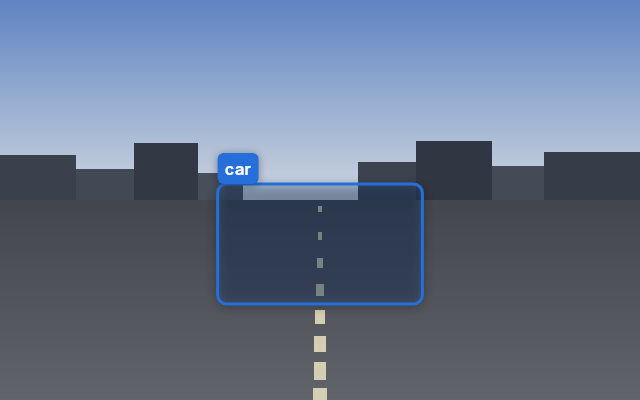

In [4]:
detection = Detection(
    class_name="car",
    boundingbox={"x": 0.34, "y": 0.46, "w": 0.32, "h": 0.3},
)

Image(SCENE).add(detection)

## 1.2 A whole record

`DatasetRecord` is what a dataset generator yields and what `LuxonisLoader`
round-trips. Everything below is plain data — no vizlab types — and one
`visualize_record` call resolves all of it: the ground surfaces as semantic
masks, an instance-segmented truck, a car with a nested plate carrying its OCR
text, a pedestrian with a pose, class-only detections as image-level tags, and
`sample_metadata` as the side panel.

This is the whole library in one call; the rest of the notebook is the pieces.

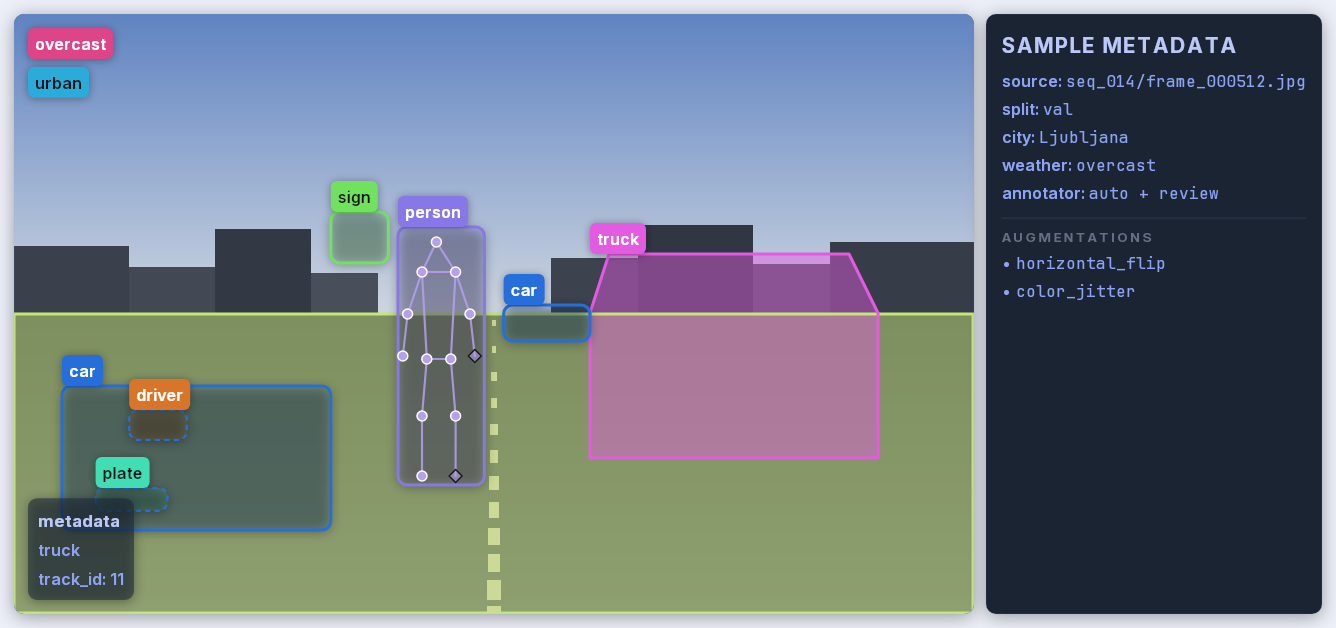

In [5]:
POSE = [
    (0.440, 0.38, 2), (0.425, 0.43, 2), (0.460, 0.43, 2), (0.410, 0.50, 2),
    (0.475, 0.50, 2), (0.405, 0.57, 2), (0.480, 0.57, 1), (0.430, 0.575, 2),
    (0.455, 0.575, 2), (0.425, 0.67, 2), (0.460, 0.67, 2), (0.425, 0.77, 2),
    (0.460, 0.77, 1),
]
POSE_NAMES = [
    "nose", "l_shoulder", "r_shoulder", "l_elbow", "r_elbow", "l_wrist",
    "r_wrist", "l_hip", "r_hip", "l_knee", "r_knee", "l_ankle", "r_ankle",
]
POSE_EDGES = [
    (0, 1), (0, 2), (1, 2), (1, 3), (3, 5), (2, 4), (4, 6),
    (1, 7), (2, 8), (7, 8), (7, 9), (9, 11), (8, 10), (10, 12),
]

w, h = 960, 600
record = DatasetRecord.model_validate({
    "files": {},  # the pixels are passed to visualize_record separately
    "task_name": "scene",
    "sample_metadata": {
        "source": "seq_014/frame_000512.jpg",
        "split": "val",
        "city": "Ljubljana",
        "weather": "overcast",
        "annotator": "auto + review",
        "augmentations": ["horizontal_flip", "color_jitter"],
    },
    "annotation": [
        # Semantic segmentation of the ground surfaces, one class each.
        {"class_name": "road", "segmentation": {
            "points": [(0.0, 0.5), (1.0, 0.5), (1.0, 1.0), (0.0, 1.0)],
            "width": w, "height": h}},
        {"class_name": "sidewalk", "segmentation": {
            "points": [(0.0, 0.6), (0.2, 0.6), (0.1, 1.0), (0.0, 1.0)],
            "width": w, "height": h}},
        # An instance-segmented truck carrying tracking metadata.
        {"class_name": "truck", "instance_id": 0,
         "instance_segmentation": {
             "points": [(0.60, 0.50), (0.62, 0.40), (0.87, 0.40),
                        (0.90, 0.50), (0.90, 0.74), (0.60, 0.74)],
             "width": w, "height": h},
         "metadata": {"track_id": 11}},
        # A car with a nested licence plate (its text) and driver.
        {"class_name": "car", "instance_id": 1,
         "boundingbox": {"x": 0.05, "y": 0.62, "w": 0.28, "h": 0.24},
         "metadata": {"track_id": 4, "speed": 31.2},
         "sub_detections": {
             "plate": {"class_name": "plate",
                       "boundingbox": {"x": 0.085, "y": 0.79,
                                       "w": 0.075, "h": 0.038},
                       "metadata": {"text": "LJ 82-A31"}},
             "driver": {"class_name": "driver",
                        "boundingbox": {"x": 0.12, "y": 0.66,
                                        "w": 0.06, "h": 0.05}}}},
        # A distant car — a plain box.
        {"class_name": "car", "instance_id": 2,
         "boundingbox": {"x": 0.51, "y": 0.485, "w": 0.09, "h": 0.06},
         "metadata": {"track_id": 9}},
        # A pedestrian with a keypoint skeleton.
        {"class_name": "person", "instance_id": 3,
         "boundingbox": {"x": 0.40, "y": 0.355, "w": 0.09, "h": 0.43},
         "keypoints": {"keypoints": POSE}},
        # A sign whose recognised text rides on the label chip.
        {"class_name": "sign", "instance_id": 4,
         "boundingbox": {"x": 0.33, "y": 0.33, "w": 0.06, "h": 0.085},
         "metadata": {"text": "STOP"}},
        # Class-only detections become image-level classification tags.
        {"class_name": "overcast"},
        {"class_name": "urban"},
    ],
})

visualize_record(
    record,
    street(w, h),
    options=RenderOptions(
        skeletons={"scene": (POSE_NAMES, POSE_EDGES)},
        draw_skeletons=True,
        keypoint_label_mode="none",
    ),
)

## 1.3 Every LDF type, one at a time

The rest of §1 takes that record apart. Each cell shows the annotation dict for
one LDF type beside the picture it produces. `sample()` is just a shortcut for
wrapping a list of annotation dicts in a record.

In [6]:
def sample(annotations, *, task_name="demo", metadata=None, **kwargs):
    """Render a list of LDF annotation dicts over the street frame."""
    record = DatasetRecord.model_validate({
        "files": {},
        "task_name": task_name,
        "sample_metadata": metadata or {},
        "annotation": annotations,
    })
    return visualize_record(record, street(560, 350), **kwargs)

### `boundingbox` — object detection

`x, y` is the top-left corner, `w, h` the extent, all normalized. A `score`
lands on the chip as a percentage; without one the chip is just the class.
Colour comes from the class name, so a class keeps its colour across every
frame in a dataset.

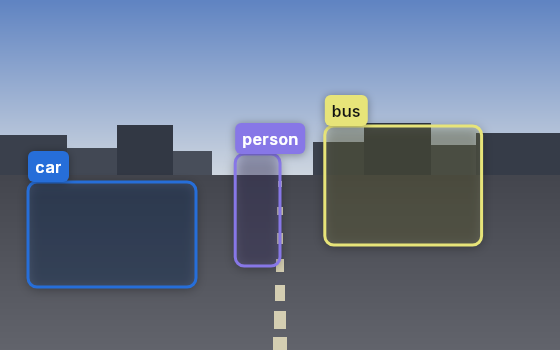

In [7]:
sample([
    {"class_name": "car", "boundingbox": {"x": 0.05, "y": 0.52, "w": 0.30, "h": 0.30}},
    {"class_name": "person", "boundingbox": {"x": 0.42, "y": 0.44, "w": 0.08, "h": 0.32}},
    {"class_name": "bus", "boundingbox": {"x": 0.58, "y": 0.36, "w": 0.28, "h": 0.34}},
])

### `sub_detections` — nested labels

A detection can own others: a plate on a car, a face on a person, a wheel on a
bike. Children derive the parent's colour — lighter, thinner, dashed — so the
hierarchy reads without a legend, and the nesting survives every transform that
touches the parent.

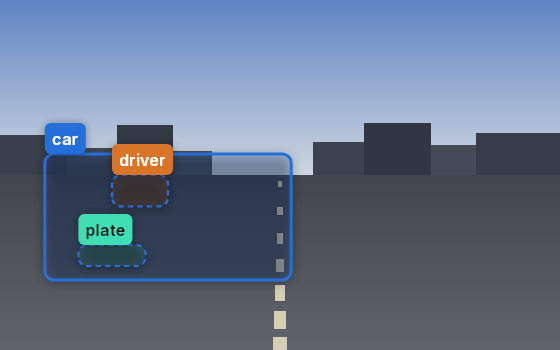

In [8]:
sample([
    {"class_name": "car",
     "boundingbox": {"x": 0.08, "y": 0.44, "w": 0.44, "h": 0.36},
     "sub_detections": {
         "plate": {"class_name": "plate",
                   "boundingbox": {"x": 0.14, "y": 0.70, "w": 0.12, "h": 0.06},
                   "metadata": {"text": "LJ 82-A31"}},
         "driver": {"class_name": "driver",
                    "boundingbox": {"x": 0.20, "y": 0.50, "w": 0.10, "h": 0.09}}}},
])

### `keypoints` — poses and landmarks

Each joint is `(x, y, visibility)` with COCO visibility: `2` visible (a solid
dot), `1` occluded (a hollow ring), `0` absent (not drawn). Skeleton edges are
not part of the annotation — they belong to the *task*, so they are passed once
in `RenderOptions.skeletons` keyed by task name and switched on with
`draw_skeletons`.

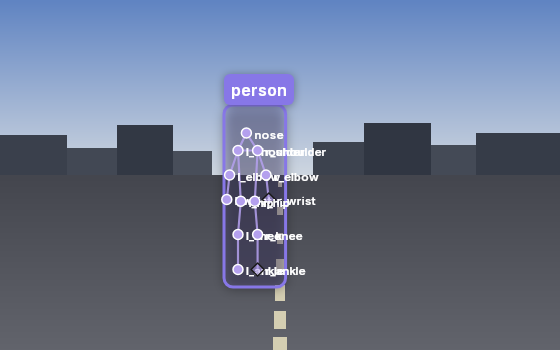

In [9]:
sample(
    [{"class_name": "person",
      "boundingbox": {"x": 0.40, "y": 0.30, "w": 0.11, "h": 0.52},
      "keypoints": {"keypoints": POSE}}],
    task_name="pose",
    options=RenderOptions(
        skeletons={"pose": (POSE_NAMES, POSE_EDGES)},
        draw_skeletons=True,
        keypoint_label_mode="names",
    ),
)

### `instance_segmentation` — one mask per object

A per-instance mask. LDF accepts it as normalized polygon `points` (with the
image `width`/`height` to rasterise against), as a binary numpy array or `.npy`
/ `.png` path under `mask`, or as COCO run-length `counts`. All three land in
the same place; the polygon form is used here because it is readable.

The outline is traced and smoothed, and the class chip is placed off the mask's
own shape rather than a bounding box.

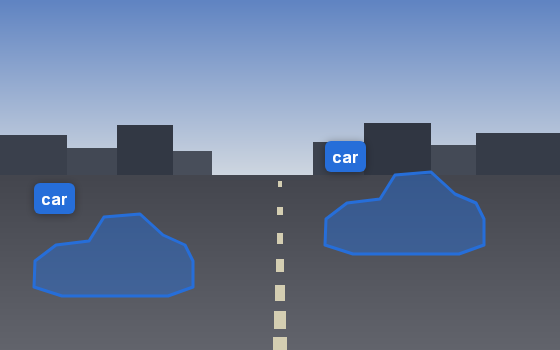

In [10]:
CAR = [
    (0.06, 0.82), (0.06, 0.75), (0.10, 0.70), (0.16, 0.685), (0.185, 0.62),
    (0.25, 0.61), (0.29, 0.67), (0.33, 0.70), (0.345, 0.75), (0.345, 0.82),
    (0.30, 0.845), (0.11, 0.845),
]

sample([
    {"class_name": "car", "instance_id": 0,
     "instance_segmentation": {"points": CAR, "width": 560, "height": 350}},
    {"class_name": "car", "instance_id": 1,
     "instance_segmentation": {
         "points": [(x + 0.52, y - 0.12) for x, y in CAR],
         "width": 560, "height": 350}},
])

### `segmentation` — dense semantic classes

The same annotation type, read as *stuff* rather than *things*. Each class
arrives as its own mask and `visualize_record` merges them into one dense
`SemanticMask` — so a pixel belongs to exactly one class, and the classes are
coloured from the same palette the boxes use. Background is index `0` and left
undrawn (`data inspect --show-background` turns it on).

Because there are no boxes to hang class chips on, this is the one case that
wants an explicit `Legend`.

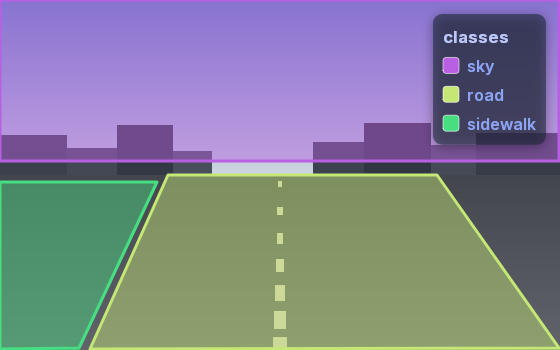

In [11]:
seg = sample([
    {"class_name": "sky", "segmentation": {
        "points": [(0.0, 0.0), (1.0, 0.0), (1.0, 0.46), (0.0, 0.46)],
        "width": 560, "height": 350}},
    {"class_name": "road", "segmentation": {
        "points": [(0.30, 0.5), (0.78, 0.5), (1.0, 1.0), (0.16, 1.0)],
        "width": 560, "height": 350}},
    {"class_name": "sidewalk", "segmentation": {
        "points": [(0.0, 0.52), (0.28, 0.52), (0.14, 1.0), (0.0, 1.0)],
        "width": 560, "height": 350}},
])
seg.add(Legend(entries=["sky", "road", "sidewalk"], title="classes",
               corner=Corner.TOP_RIGHT))

### `classification` — image-level tags

A detection with a class name and no geometry is a statement about the whole
sample, so it is drawn as a corner tag rather than as a shape. Several stack
into a multi-label block.

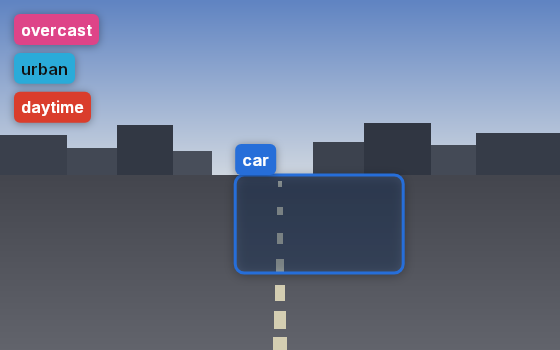

In [12]:
sample([
    {"class_name": "overcast"},
    {"class_name": "urban"},
    {"class_name": "daytime"},
    {"class_name": "car", "boundingbox": {"x": 0.42, "y": 0.5, "w": 0.3, "h": 0.28}},
])

### `metadata` — tracks, text, and anything else

Per-detection metadata is free-form, and it is deliberately **not** burned into
the pixels — that is how dense scenes stay readable. Where it goes depends on
whether there is anything to hover:

- a **boxed** detection's metadata becomes a hover `Tooltip`, drawn by the
  interactive viewer (§8) and the HTML export (§7). It is off by default; turn
  it on with `RenderOptions(hover_metadata=True)` or `data inspect`'s
  `--color-by instance`.
- a **box-less** detection has nothing to hover, so its metadata is surfaced as
  a `metadata` corner card instead. That is what the card in §1.2 is: the truck
  is an instance mask with no box.

`sample_metadata` is the sample-level counterpart, and becomes the side panel.

To put text *on* the chip — the OCR case — use the render annotation's
`payload` (§2.1); the LDF adapter does not promote any metadata key to it.

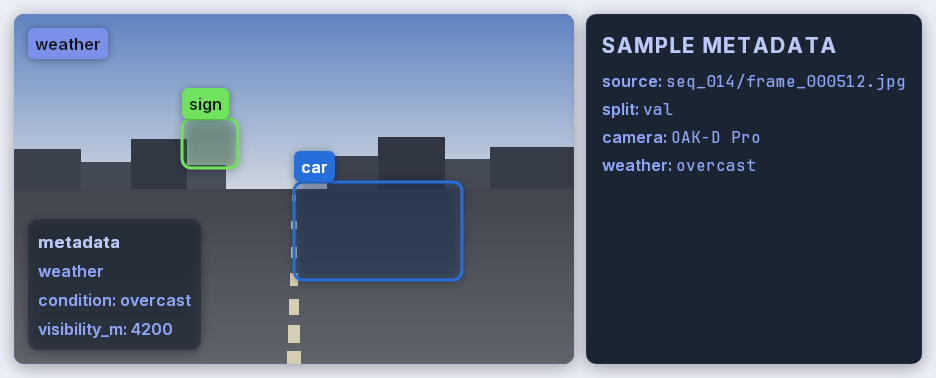

In [13]:
sample(
    [
        {"class_name": "sign",
         "boundingbox": {"x": 0.30, "y": 0.30, "w": 0.10, "h": 0.14},
         "metadata": {"text": "STOP", "confidence": 0.97}},   # -> hover
        {"class_name": "car",
         "boundingbox": {"x": 0.50, "y": 0.48, "w": 0.30, "h": 0.28},
         "metadata": {"track_id": 4, "speed": 31.2}},          # -> hover
        {"class_name": "weather", "metadata": {"condition": "overcast",
                                               "visibility_m": 4200}},  # -> card
    ],
    metadata={"source": "seq_014/frame_000512.jpg", "split": "val",
              "camera": "OAK-D Pro", "weather": "overcast"},
    options=RenderOptions(hover_metadata=True),
)

### `array` — the escape hatch

An `array` label is a bare `.npy` path: a disparity map, an optical flow field,
a per-class score stack, an embedding. Nothing in the data says what the numbers
*mean*, so vizlab does not guess loudly — array drawing is **off by default**
and switched on with `RenderOptions.array_view` (`data inspect --array-viz`).

How a given array is read comes from the most deliberate signal available: an
explicit pin (`array_kinds`, or `--array-kind <task> <kind>`), then a reserved
task name like `disparity` or `flow`, then the shape. §3 draws every reading.

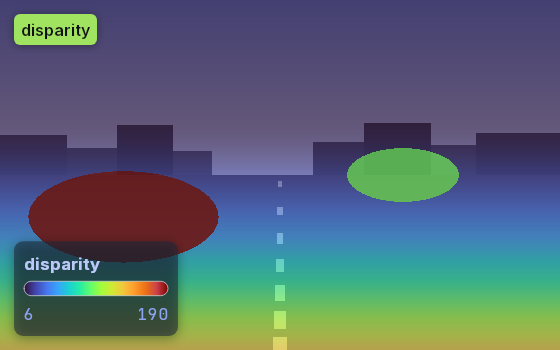

In [14]:
import tempfile
from pathlib import Path

scratch = Path(tempfile.mkdtemp(prefix="vizlab_notebook_"))
np.save(scratch / "disparity.npy", disparity(560, 350).astype(np.float32))

sample(
    [{"class_name": "disparity", "array": {"path": str(scratch / "disparity.npy")}}],
    task_name="disparity",  # a reserved name: read as a scalar field
    options=RenderOptions(array_view="overlay"),
)

<a id="1.9"></a>
## 1.9 The round trip: a real `LuxonisDataset`

Everything above hand-built its records. In practice they come out of a loader.
This builds a throwaway four-frame dataset on disk, reads it back with
`LuxonisLoader`, and converts the loader's tensors into the very same
`DatasetRecord` objects — `loader_output_to_records` is the bridge, and it is
exactly what `luxonis_ml data inspect` uses.

Needs the `data` extra; the cell skips itself if it is missing.

In [15]:
try:
    import cv2

    from luxonis_ml.data import LuxonisDataset, LuxonisLoader
    from luxonis_ml.data.loaders.label_converter import loader_output_to_records
except ImportError as error:
    print(f"skipping: {error} (pip install 'luxonis-ml[data]')")
    dataset = None
else:
    from luxonis_ml.utils import setup_logging

    # Building a dataset is chatty; the notebook only cares about the result.
    setup_logging(level="WARNING")

    frames = scratch / "frames"
    frames.mkdir(exist_ok=True)

    def generate():
        """Four street frames, each with a car crossing and a pedestrian.

        The pixels have to actually differ between frames: LDF identifies a
        file by the hash of its contents, so four identical images would be
        stored as one sample carrying all eight annotations.
        """
        for i in range(4):
            path = frames / f"frame_{i:03d}.png"
            offset = 0.06 + 0.18 * i
            pixels = street(480, 300)
            x0, y0 = int(offset * 480), int(0.52 * 300)
            pixels[y0 : y0 + 78, x0 : x0 + 125] = (58, 74, 120)  # the car
            pixels[131:221, 374:408] = (96, 84, 78)              # the pedestrian
            cv2.imwrite(str(path), pixels[..., ::-1])
            yield {
                "file": str(path),
                "task_name": "traffic",
                "annotation": {
                    "class_name": "car",
                    "boundingbox": {"x": offset, "y": 0.52,
                                    "w": 0.26, "h": 0.26},
                    "metadata": {"track_id": i, "speed": 30.0 + 4.0 * i},
                },
            }
            yield {
                "file": str(path),
                "task_name": "traffic",
                "annotation": {
                    "class_name": "person",
                    "boundingbox": {"x": 0.78, "y": 0.44, "w": 0.07, "h": 0.3},
                },
            }

    dataset = LuxonisDataset("vizlab_notebook_demo", delete_local=True)
    dataset.add(generate())
    dataset.make_splits({"train": 1.0})
    print(f"{len(dataset)} samples, classes: {dataset.get_class_names()}")

Output()

4 samples, classes: {'traffic': ['car', 'person']}


Now read it back. Each loader output becomes a `DatasetRecord`, which
`visualize_record` draws — the same call as §1.2, now on data that made a full
round trip through the dataset format.

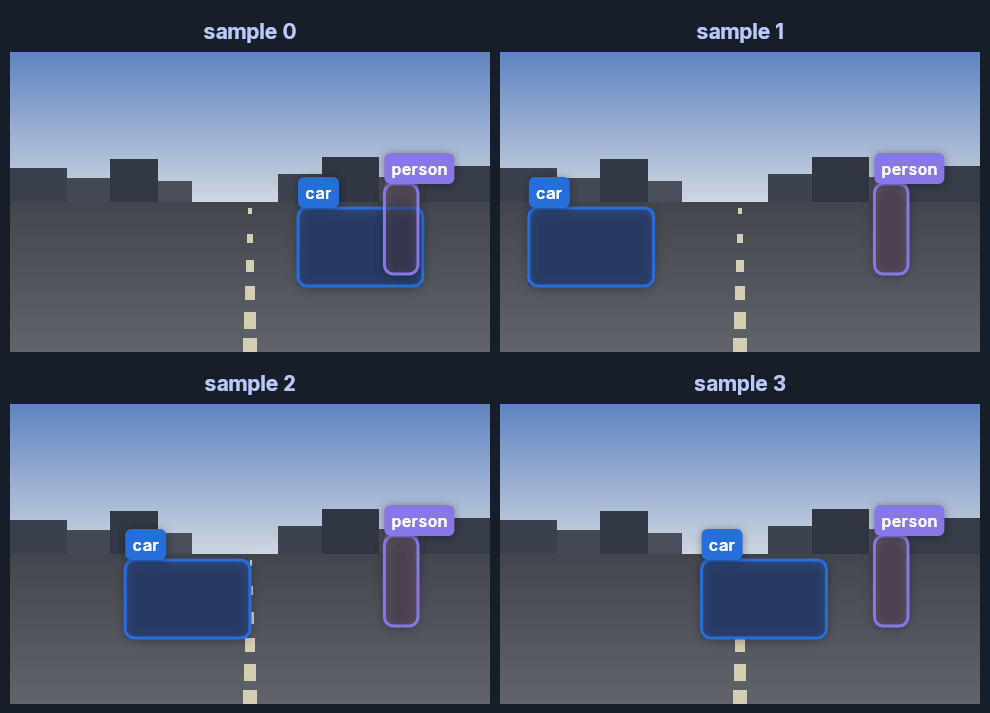

In [16]:
if dataset is not None:
    classes = dataset.get_classes()
    encodings = dataset.get_categorical_encodings()

    rendered = []
    for data in LuxonisLoader(dataset, view="train"):
        image = next(iter(data.images.values()))
        records = loader_output_to_records(
            data.labels, classes=classes, categorical_encodings=encodings
        )
        record = next(iter(records.values()))
        rendered.append(visualize_record(record, image))

    figure = grid(rendered, ncols=2, titles=[f"sample {i}" for i in range(len(rendered))])
else:
    figure = None
figure

The interactive equivalent, from a shell — the same renderer, driven by keys and
a clickable side panel:

```bash
luxonis_ml data inspect vizlab_notebook_demo
luxonis_ml data inspect coco --color-by instance --skeletons --array-viz
luxonis_ml data inspect coco --class-name person --min-instances 3 --save contact.png
```

`data inspect` is the CLI face of everything in this notebook: `--theme`,
`--array-kind`, `--aug-config`, filters over classes/metadata/instance counts,
and `--save` to a PNG, an HTML page, or a video clip. §8 runs the same viewer
inside this notebook.

<a id="2"></a>
# 2. The annotation types up close

The LDF path infers what to draw. When you are drawing **model output** — or
anything that is not a dataset record — you build the annotations yourself.
These are the same objects `visualize_record` produces internally.

Here is the whole vocabulary on one page; the cells after it take each area in
turn.

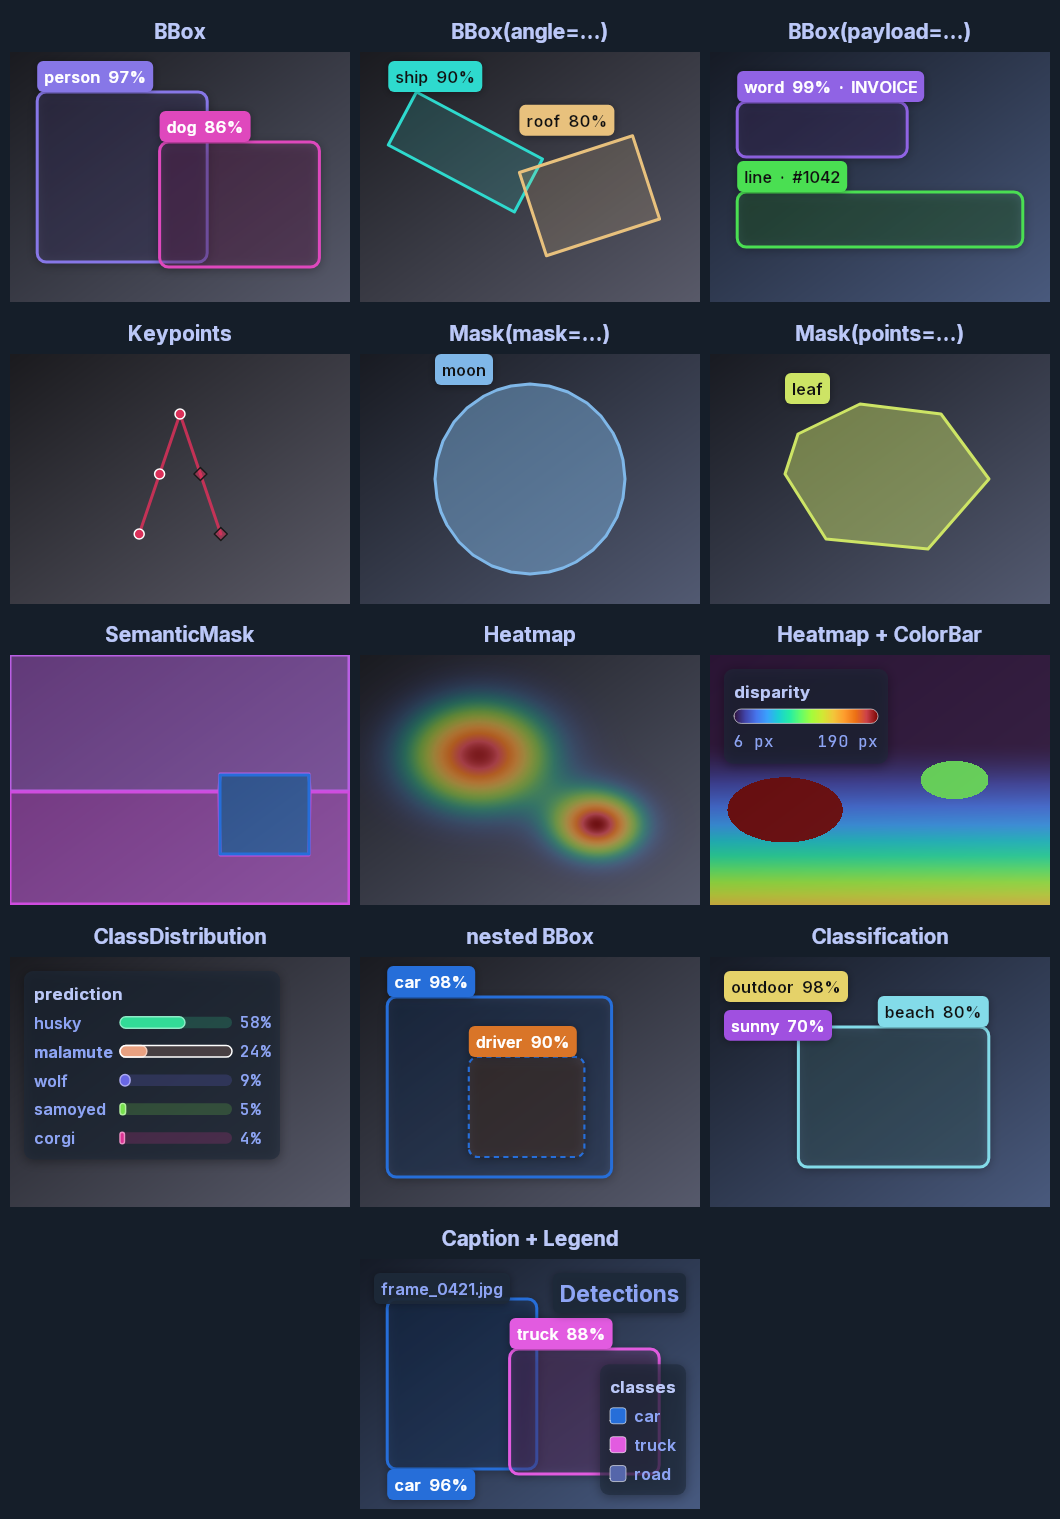

In [17]:
def cell(hue=0.58, size=(W, H)):
    return Image(ramp(size[0], size[1], hue=hue))


boxes = (
    cell()
    .add(BBox(x=0.08, y=0.16, w=0.5, h=0.68, label="person", score=0.97))
    .add(BBox(x=0.44, y=0.36, w=0.47, h=0.5, label="dog", score=0.86))
)
oriented = (
    cell(0.62)
    .add(BBox(x=0.1, y=0.28, w=0.42, h=0.24, angle=28, label="ship", score=0.9))
    .add(BBox(x=0.5, y=0.4, w=0.35, h=0.35, angle=-18, label="roof", score=0.8))
)
payload = (
    cell(0.12)
    .add(BBox(x=0.08, y=0.2, w=0.5, h=0.22, label="word", score=0.99, payload="INVOICE"))
    .add(BBox(x=0.08, y=0.56, w=0.84, h=0.22, label="line", payload="#1042"))
)
nested_box = BBox(x=0.08, y=0.16, w=0.66, h=0.72, label="car", score=0.98)
nested_box.add(BBox(x=0.32, y=0.4, w=0.34, h=0.4, label="driver", score=0.9))
nested = cell(0.55).add(nested_box)

pose = cell(0.68).add(
    Keypoints(
        keypoints=[(0.5, 0.24, 2), (0.44, 0.48, 2), (0.56, 0.48, 1),
                   (0.38, 0.72, 2), (0.62, 0.72, 1)],
        edges=[(0, 1), (0, 2), (1, 3), (2, 4)],
        label="pose",
    )
)

ys, xs = np.ogrid[:H, :W]
instance = cell(0.4).add(
    Mask(mask=((xs - 170) ** 2 + (ys - 125) ** 2 <= 95**2).astype(np.uint8), label="moon")
)
polygon = cell(0.44).add(
    Mask(points=[(0.26, 0.32), (0.44, 0.2), (0.68, 0.24), (0.82, 0.5),
                 (0.64, 0.78), (0.34, 0.74), (0.22, 0.48)],
         width=W, height=H, label="leaf")
)

labels = np.zeros((H, W), dtype=np.int32)
labels[: int(H * 0.55)] = 1
labels[int(H * 0.55) :] = 2
labels[120:200, 210:300] = 3
semantic = cell(0.5).add(
    SemanticMask(labels=labels,
                 names={0: "background", 1: "sky", 2: "ground", 3: "car"},
                 ignore_index=0)
)

heat = cell(0.55).add(Heatmap(values=blobs(W, H, [(0.35, 0.4, 0.16), (0.7, 0.68, 0.1)])))

field = Heatmap(values=disparity(W, H), weight_by_value=False, alpha=0.75)
keyed = cell(0.55).add(field).add(
    ColorBar.for_heatmap(field, title="disparity", unit="px", corner=Corner.TOP_LEFT)
)

PREDICTION = {"husky": 0.58, "malamute": 0.24, "wolf": 0.09,
              "samoyed": 0.05, "corgi": 0.04}
distribution = cell(0.6).add(
    ClassDistribution(probabilities=PREDICTION, ground_truth="malamute",
                      title="prediction")
)
tags = (
    cell(0.12)
    .add(BBox(x=0.26, y=0.28, w=0.56, h=0.56, label="beach", score=0.8))
    .add(Classification(tags=[("outdoor", 0.98), ("sunny", 0.7)], corner=Corner.TOP_LEFT))
)
chrome = (
    cell(0.05)
    .add(BBox(x=0.08, y=0.16, w=0.44, h=0.68, label="car", score=0.96))
    .add(BBox(x=0.44, y=0.36, w=0.44, h=0.5, label="truck", score=0.88))
    .add(Caption(text="frame_0421.jpg", corner=Corner.TOP_LEFT))
    .add(Caption(text="Detections", title=True, corner=Corner.TOP_RIGHT))
    .add(Legend(entries=["car", "truck", ("road", "#5566aa")], title="classes",
                corner=Corner.BOTTOM_RIGHT))
)

overview = {
    "BBox": boxes, "BBox(angle=…)": oriented, "BBox(payload=…)": payload,
    "Keypoints": pose, "Mask(mask=…)": instance, "Mask(points=…)": polygon,
    "SemanticMask": semantic, "Heatmap": heat, "Heatmap + ColorBar": keyed,
    "ClassDistribution": distribution, "nested BBox": nested,
    "Classification": tags, "Caption + Legend": chrome,
}
grid(list(overview.values()), ncols=3, titles=list(overview))

## 2.1 Boxes

`BBox` covers four cases that all reduce to the same four numbers:

- **plain** — a class and, optionally, a score;
- **oriented** — `angle` (degrees about the box centre) for aerial imagery,
  scene text, and rotated-object detectors;
- **payload** — free text on the chip beside the class, which is how OCR
  transcriptions ride along;
- **nested** — `add` a child and its style is derived from the parent's.

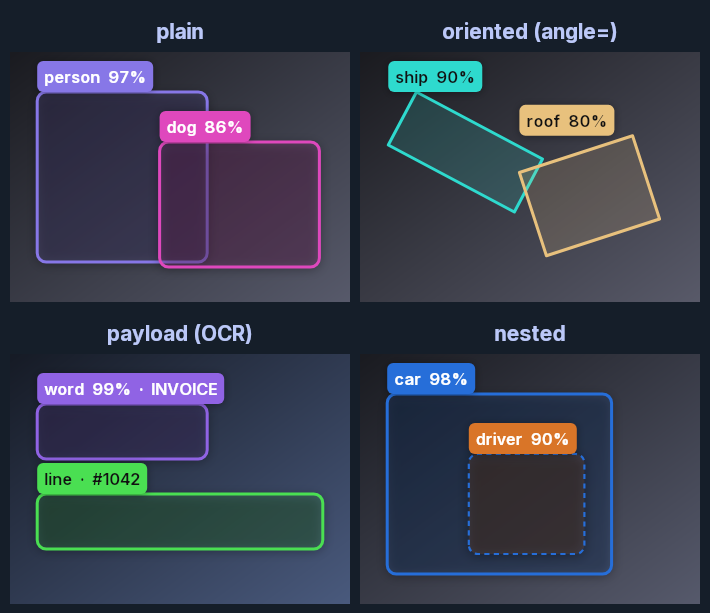

In [18]:
grid([boxes, oriented, payload, nested], ncols=2,
     titles=["plain", "oriented (angle=)", "payload (OCR)", "nested"])

## 2.2 Keypoints and masks

`Keypoints` grades each joint by visibility and joins them with `edges`.
`Mask` takes either a binary array or a normalized polygon — the same instance
mask either way. `SemanticMask` takes a dense integer label map plus the class
names, and colours per class id.

`point_labels` puts joint numbers or names on the pose; `MaskOutline` chooses
between a smoothed contour, an exact one, and none at all.

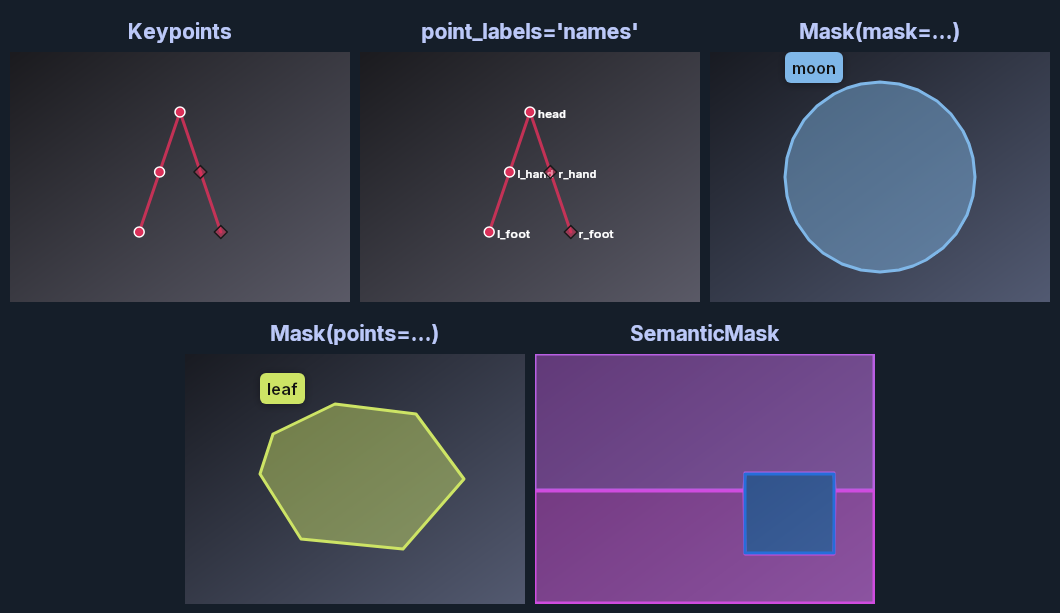

In [19]:
named_pose = cell(0.68).add(
    Keypoints(
        keypoints=[(0.5, 0.24, 2), (0.44, 0.48, 2), (0.56, 0.48, 1),
                   (0.38, 0.72, 2), (0.62, 0.72, 1)],
        edges=[(0, 1), (0, 2), (1, 3), (2, 4)],
        keypoint_names=["head", "l_hand", "r_hand", "l_foot", "r_foot"],
        point_labels="names",
        label="pose",
    )
)

grid([pose, named_pose, instance, polygon, semantic], ncols=3,
     titles=["Keypoints", "point_labels='names'", "Mask(mask=…)",
             "Mask(points=…)", "SemanticMask"])

## 2.3 Overlays

Things drawn *over* the frame rather than in it. They take a `Corner` and stack
in it, so several can share a corner without colliding: `Classification` for
image-level tags, `Caption` for a filename or a title, `Legend` for the class
colour key, `InfoCard` for free rows of text, and `ClassDistribution` for a
prediction as what it actually is — a distribution, not one class.

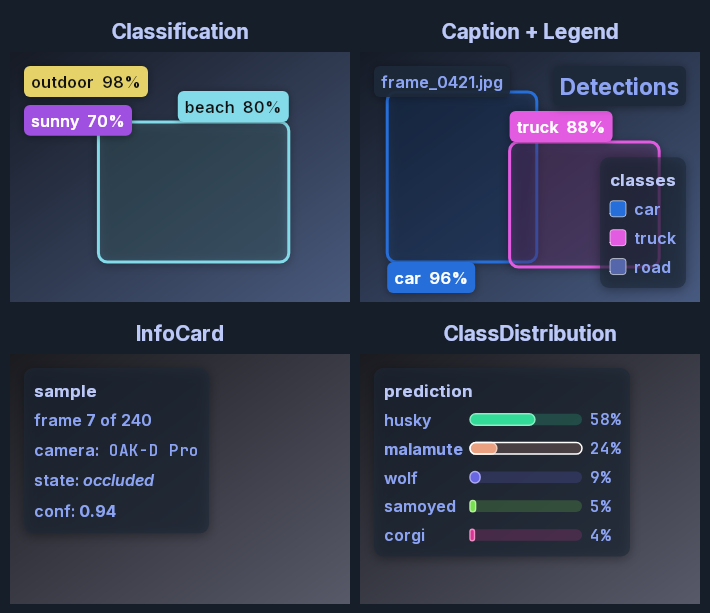

In [20]:
card = cell(0.62).add(
    InfoCard(
        rows=["frame <b>7</b> of 240", "camera: <code>OAK-D Pro</code>",
              "state: <i>occluded</i>", "conf: <b>0.94</b>"],
        title="<b>sample</b>",
        corner=Corner.TOP_LEFT,
    )
)

grid([tags, chrome, card, distribution], ncols=2,
     titles=["Classification", "Caption + Legend", "InfoCard", "ClassDistribution"])

A prediction is a distribution, and `mode` picks how to say so. `ground_truth`
marks the correct class in every mode — a row, a chip, a segment, a wedge, or a
✓/✗ on the gauge — so a wrong top-1 (as here: the model says *husky*, the truth
is *malamute*) is obvious at a glance.

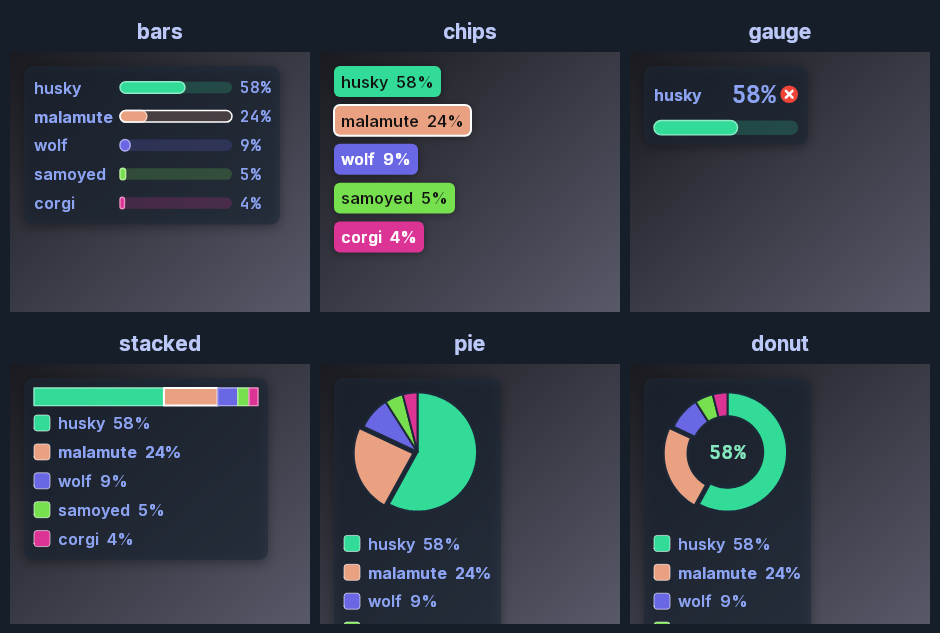

In [21]:
modes = ["bars", "chips", "gauge", "stacked", "pie", "donut"]
grid(
    [
        Image(ramp(300, 260, hue=0.6)).add(
            ClassDistribution(probabilities=PREDICTION, mode=mode,
                              ground_truth="malamute", corner=Corner.TOP_LEFT)
        )
        for mode in modes
    ],
    ncols=3,
    titles=modes,
)

<a id="3"></a>
# 3. Dense fields and arrays

A `Heatmap` colours a scalar field through a gradient and blends it over the
image. That covers saliency and attention maps; the LDF `array` label needs
more, because "an array" is not one kind of picture.

## 3.1 Gradients

`gradient` takes any built-in name or a `Gradient` you build yourself. The
default is `turbo`.

viridis, magma, inferno, plasma, turbo, jet, hot, coolwarm, rdbu, seismic, grayscale


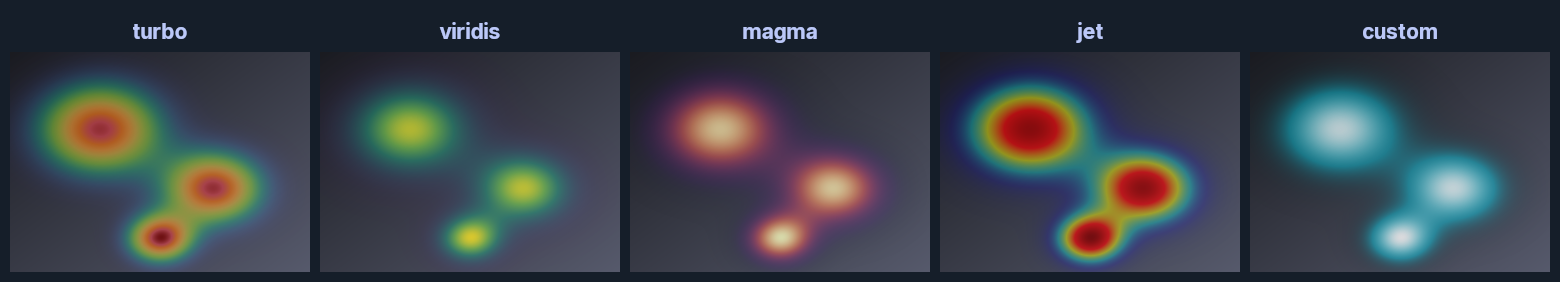

In [22]:
from luxonis_ml.vizlab import GRADIENTS

print(", ".join(GRADIENTS))

saliency = blobs(300, 220, [(0.3, 0.35, 0.15), (0.68, 0.62, 0.12), (0.5, 0.85, 0.08)])
themes = ["turbo", "viridis", "magma", "jet",
          Gradient.from_colors(["#000000", "#00e5ff", "#ffffff"])]
grid(
    [Image(ramp(300, 220, hue=0.55)).add(Heatmap(values=saliency, gradient=theme))
     for theme in themes],
    ncols=5,
    titles=["turbo", "viridis", "magma", "jet", "custom"],
)

## 3.2 The colour key

A heatmap says which pixel is hotter; only a key says what "hot" *is*. Build one
with `ColorBar.for_heatmap` and it copies the field's gradient and resolved
range, so the two cannot drift apart. Keys stack with a `Legend` rather than
covering it, so one scene can carry both a class palette and a continuous scale.

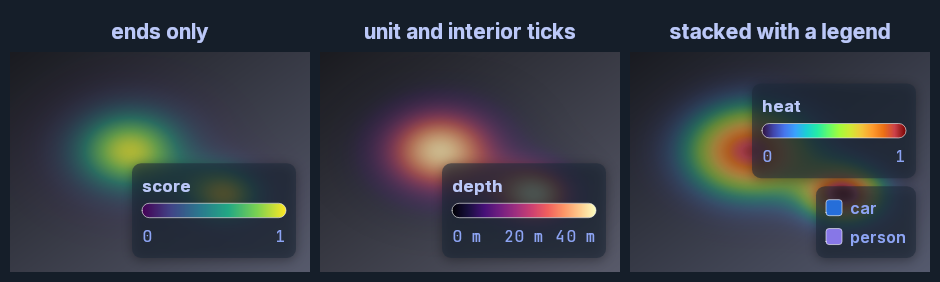

In [23]:
field = blobs(300, 220, [(0.4, 0.45, 0.16), (0.72, 0.65, 0.1)])
grid(
    [
        Image(ramp(300, 220, hue=0.55))
        .add(Heatmap(values=field, gradient="viridis"))
        .add(ColorBar(gradient="viridis", vmax=1.0, title="score")),
        Image(ramp(300, 220, hue=0.6))
        .add(Heatmap(values=field * 40.0, gradient="magma"))
        .add(ColorBar(gradient="magma", vmax=40.0, title="depth", unit="m", ticks=3)),
        Image(ramp(300, 220, hue=0.5))
        .add(Heatmap(values=field, gradient="turbo"))
        .add(Legend(entries=["car", "person"], corner=Corner.BOTTOM_RIGHT))
        .add(ColorBar(vmax=1.0, title="heat", corner=Corner.BOTTOM_RIGHT)),
    ],
    ncols=3,
    titles=["ends only", "unit and interior ticks", "stacked with a legend"],
)

## 3.3 Every reading of an array

The same LDF `array` label, eight ways. There is no single right picture for an
array, which is exactly why these are separate annotation types rather than one
type with a mode — and why `data inspect` makes you say which you meant when
the shape is ambiguous (`--array-kind <task> <kind>`).

- **scalar** — depth, disparity, uncertainty: one gradient, low to high.
- **signed** — an error map straddles zero, so it needs a diverging gradient
  centred there; the one case a sequential ramp cannot show honestly.
- **flow** — two channels; hue is heading and saturation is speed, keyed by the
  `FlowWheel` rather than a bar.
- **normals** — xyz as RGB, the convention every renderer uses.
- **image** — the array already *is* a picture; draw it.
- **scores** — a per-class stack argmaxed into a `SemanticMask`.
- **confidence** — the same stack read the other way: not which class won, but
  by how much. The boundaries are where the model was actually deciding.
- **class confidence** — both at once: hue for the winning class, solidity for
  the margin, so hesitation is visible without losing the classes.

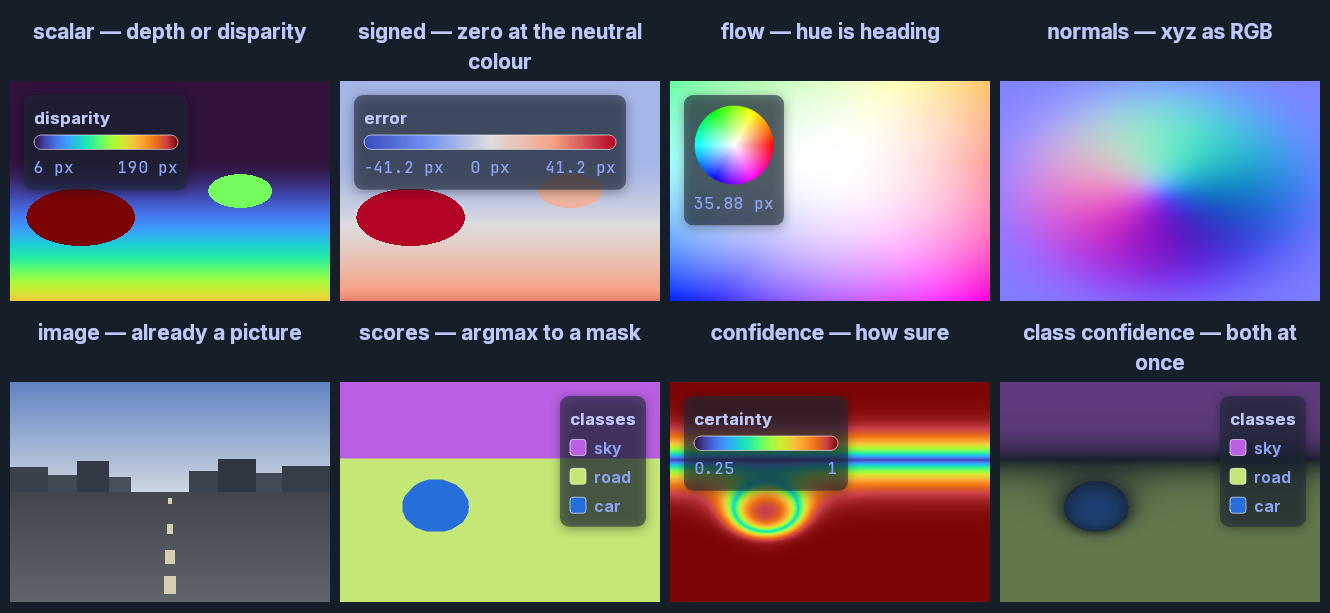

In [24]:
aw, ah = 320, 220
photo = street(aw, ah)
plate = np.full((ah, aw, 3), DARK_THEME.background.rgb, dtype=np.uint8)

depth = disparity(aw, ah)
error = depth - disparity(aw, ah) * 0.72 - 12.0  # a prediction minus the truth
stack = scores(aw, ah)
names = ["background", "sky", "road", "car"]

scalar = ScalarField(values=depth)
signed = ScalarField(values=error, center=0.0)
motion = FlowField(values=flow(aw, ah))
classes_field = SegmentationScores(values=stack, names=names)
certainty = classes_field.confidence()
weighted = SegmentationScores(
    values=stack, names=names, weight_by_confidence=True,
    # A crisp outline would contradict a fill that fades precisely because the
    # boundary is where the model was least sure of it.
    contour=False,
)
key = Legend(entries=["sky", "road", "car"], title="classes", corner=Corner.TOP_RIGHT)

grid(
    [
        Image(plate).add(scalar).add(ColorBar.for_heatmap(
            scalar, title="disparity", unit="px", corner=Corner.TOP_LEFT)),
        Image(plate).add(signed).add(ColorBar.for_heatmap(
            signed, title="error", unit="px", corner=Corner.TOP_LEFT)),
        Image(plate).add(motion).add(FlowWheel.for_field(motion, corner=Corner.TOP_LEFT)),
        Image(plate).add(NormalMap(values=normals(aw, ah))),
        Image(plate).add(ArrayImage(values=photo.astype(np.float32) / 255.0)),
        Image(plate).add(classes_field).add(key),
        Image(plate).add(certainty).add(ColorBar.for_heatmap(
            certainty, title="certainty", corner=Corner.TOP_LEFT)),
        Image(plate).add(weighted).add(key),
    ],
    ncols=4,
    titles=["scalar — depth or disparity", "signed — zero at the neutral colour",
            "flow — hue is heading", "normals — xyz as RGB",
            "image — already a picture", "scores — argmax to a mask",
            "confidence — how sure", "class confidence — both at once"],
)

## 3.4 Ranges, holes, and honest comparisons

Two traps worth knowing about, both of which quietly produce a *convincing*
wrong picture.

**Auto-scaling hides differences.** Every field is stretched to its own extremes
by default, so a sensor that reads 45% low looks identical to the truth. Only a
pinned `vmin`/`vmax` (or `--array-vmin`/`--array-vmax`) shows it.

**A no-data sentinel is not a small value.** A stereo gap stored as `0.0` reads
as "very far away" unless `ignore_value` drops it out of both the range and the
drawing, leaving a hole that says *not measured*.

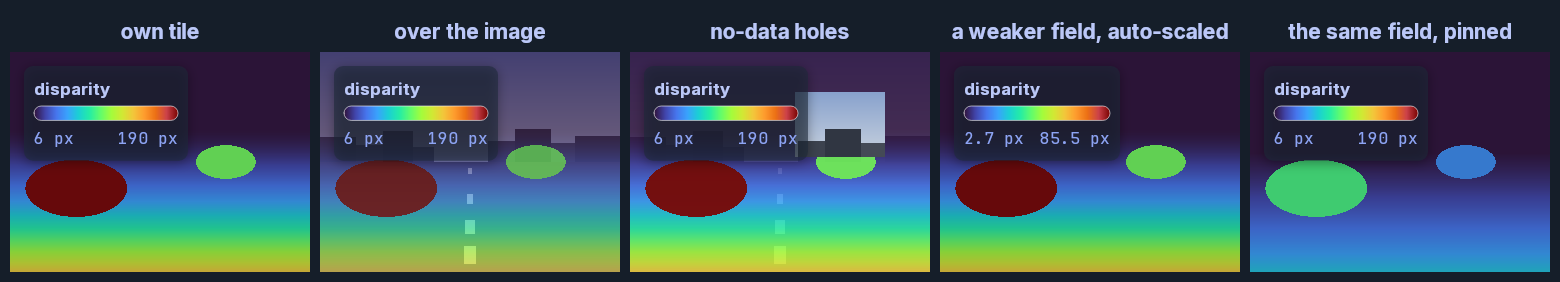

In [25]:
depth = disparity(300, 220)
holed = depth.copy()
holed[40:105, 165:255] = 0.0     # an unmatched region, marked with a sentinel
weaker = depth * 0.45            # the same scene, measured 55% low
photo = street(300, 220)
plate = np.full((220, 300, 3), DARK_THEME.background.rgb, dtype=np.uint8)

fields = [
    (plate, Heatmap(values=depth, weight_by_value=False)),
    (photo, Heatmap(values=depth, weight_by_value=False, alpha=0.6)),
    (photo, Heatmap(values=holed, weight_by_value=False, alpha=0.85, ignore_value=0.0)),
    (plate, Heatmap(values=weaker, weight_by_value=False)),
    (plate, Heatmap(values=weaker, weight_by_value=False,
                    vmin=float(depth.min()), vmax=float(depth.max()))),
]
grid(
    [
        Image(base).add(heat).add(ColorBar.for_heatmap(
            # Top-left: the sky, the one part of a driving frame with nothing in
            # it. A key must not cover what it describes.
            heat, title="disparity", unit="px", corner=Corner.TOP_LEFT))
        for base, heat in fields
    ],
    ncols=5,
    titles=["own tile", "over the image", "no-data holes",
            "a weaker field, auto-scaled", "the same field, pinned"],
)

<a id="4"></a>
# 4. Appearance

Four levers, broadest to most local. Each one wins over the ones above it.

1. **`Theme`** — the default `Style` plus the class `Palette`. `DARK_THEME` is
   the default; `LIGHT_THEME` ships too.
2. **`RenderOptions`** — a theme plus the gradient and LDF behaviour, handed to
   an image with `Image(options=…)` or installed for a scope with
   `default_options`.
3. **`Annotation.styled(...)`** — a few fields layered over the theme, or a whole
   `Style` to replace it; `color=` pins one annotation's colour.
4. **`Style.override(...)`** — a `with` block every render inside it picks up.

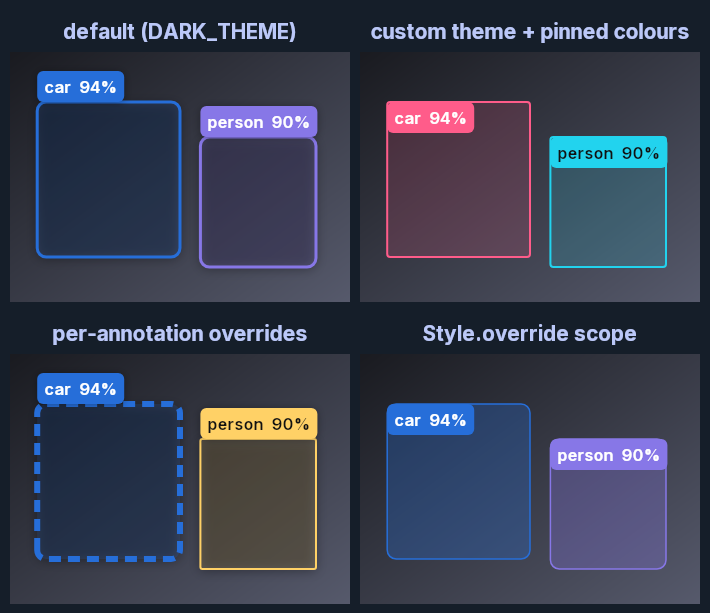

In [26]:
def two_boxes(options=None):
    return (
        Image(ramp(hue=0.55), options=options)
        .add(BBox(x=0.08, y=0.2, w=0.42, h=0.62, label="car", score=0.94))
        .add(BBox(x=0.56, y=0.34, w=0.34, h=0.52, label="person", score=0.9))
    )


house = Style(
    stroke_width=2.0, corner_radius=3.0, shadow=False,
    font_family="mono", label_placement=LabelPlacement.INSIDE,
)
themed = two_boxes(
    RenderOptions(
        theme=DARK_THEME.with_style(house).with_class_colors(
            {"car": "#ff5c8a", "person": "#22d3ee"}
        )
    )
)

local = (
    Image(ramp(hue=0.55))
    .add(BBox(x=0.08, y=0.2, w=0.42, h=0.62, label="car", score=0.94)
         .styled(stroke_width=6.0, dash=(12.0, 7.0)))
    .add(BBox(x=0.56, y=0.34, w=0.34, h=0.52, label="person", score=0.9,
              color="#ffd166")
         .styled(Style(stroke_width=2.0, corner_radius=2.0)))
)

# Scopes apply at render time, so the scene is rendered inside the block and the
# resulting pixels wrapped back up.
with Style.override(stroke_width=1.5, fill_alpha=0.3, shadow=False,
                    label_placement=LabelPlacement.INSIDE):
    scoped = Image(two_boxes().render())

grid([two_boxes(), themed, local, scoped], ncols=2,
     titles=["default (DARK_THEME)", "custom theme + pinned colours",
             "per-annotation overrides", "Style.override scope"])

## 4.1 Themes

The same scene in both bundled themes. A theme carries the background too, so a
composite's padding, panel, and titles follow it.

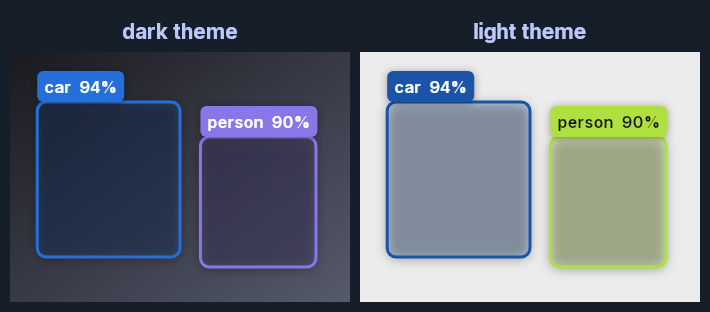

In [27]:
grid(
    [
        two_boxes(),
        Image(np.full((H, W, 3), 236, np.uint8),
              options=RenderOptions(theme=LIGHT_THEME))
        .add(BBox(x=0.08, y=0.2, w=0.42, h=0.62, label="car", score=0.94))
        .add(BBox(x=0.56, y=0.34, w=0.34, h=0.52, label="person", score=0.9)),
    ],
    ncols=2,
    titles=["dark theme", "light theme"],
)

## 4.2 Palettes

A `Palette` maps class names to colours deterministically, so a class keeps its
colour across every frame, every split, and every figure. Pin the ones that
carry meaning (red for a defect, say) and let the rest be generated.

     car  #ff5c8a
  person  #22d3ee
     bus  #e25be0
    bike  #42deb3
    sign  #d97528


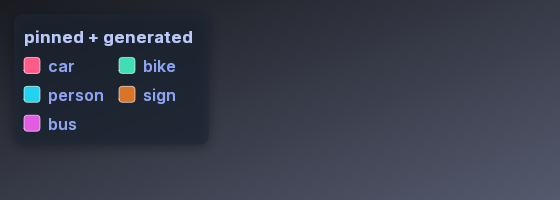

In [28]:
palette = Palette(["car", "person", "bus", "bike", "sign"]).with_colors(
    {"car": "#ff5c8a", "person": "#22d3ee"}
)
for name in ["car", "person", "bus", "bike", "sign"]:
    print(f"{name:>8}  #{'%02x%02x%02x' % palette.color_for(name).rgb}")

Image(ramp(560, 200, hue=0.5), options=RenderOptions(theme=DARK_THEME.with_palette(palette))).add(
    Legend(entries=["car", "person", "bus", "bike", "sign"],
           title="pinned + generated", corner=Corner.TOP_LEFT)
)

## 4.3 Inline markup

**Every string vizlab draws** — labels, captions, titles, panel rows, tooltips —
accepts the same Pango-style tags. Anything that is not a tag is drawn as
itself, so no escaping is needed for ordinary text; use `escape()` for text you
did not author (the LDF adapter already does this for dataset metadata).

The left half of each row below is the snippet, escaped so it shows the
characters you would type; the right half is that same string left unescaped.
Every row therefore demonstrates exactly what it documents.

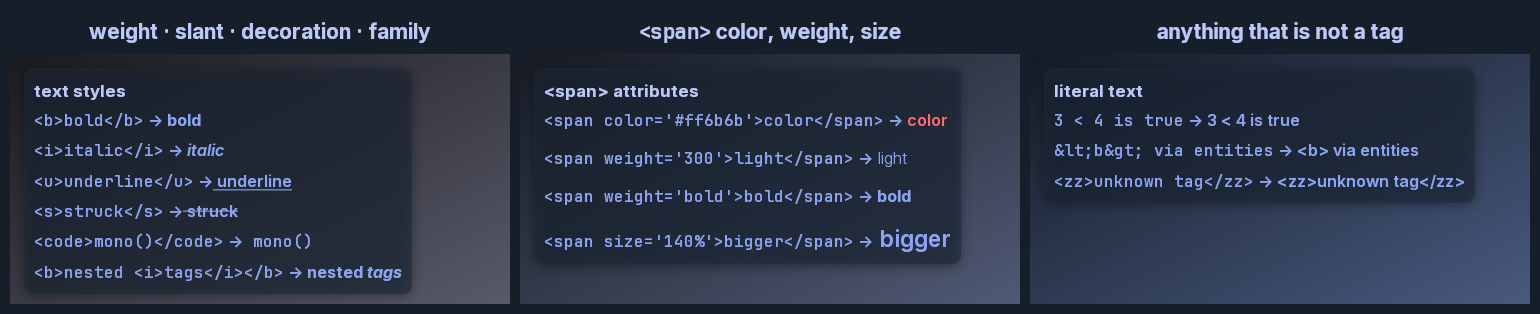

In [29]:
def reference(title, sources, hue):
    return Image(ramp(500, 250, hue=hue)).add(
        InfoCard(
            rows=[f"<code>{escape(s)}</code>  →  {s}" for s in sources],
            title=title,
            corner=Corner.TOP_LEFT,
        )
    )


grid(
    [
        reference("<b>text styles</b>",
                  ["<b>bold</b>", "<i>italic</i>", "<u>underline</u>",
                   "<s>struck</s>", "<code>mono()</code>",
                   "<b>nested <i>tags</i></b>"], 0.62),
        reference("<b>&lt;span&gt; attributes</b>",
                  ["<span color='#ff6b6b'>color</span>",
                   "<span weight='300'>light</span>",
                   "<span weight='bold'>bold</span>",
                   "<span size='140%'>bigger</span>"], 0.34),
        reference("<b>literal text</b>",
                  ["3 < 4 is true", "&lt;b&gt; via entities",
                   "<zz>unknown tag</zz>"], 0.08),
    ],
    ncols=3,
    titles=["weight · slant · decoration · family",
            "<code>&lt;span&gt;</code> color, weight, size",
            "anything that is not a tag"],
)

The same tags where they actually get used. One caveat: an annotation's `label`
doubles as its palette key and its viewer visibility key, so `<b>car</b>` and
`car` are two different classes as far as colouring and class-toggling go —
markup belongs in a label for emphasis, not for renaming. The colours below are
pinned explicitly for that reason.

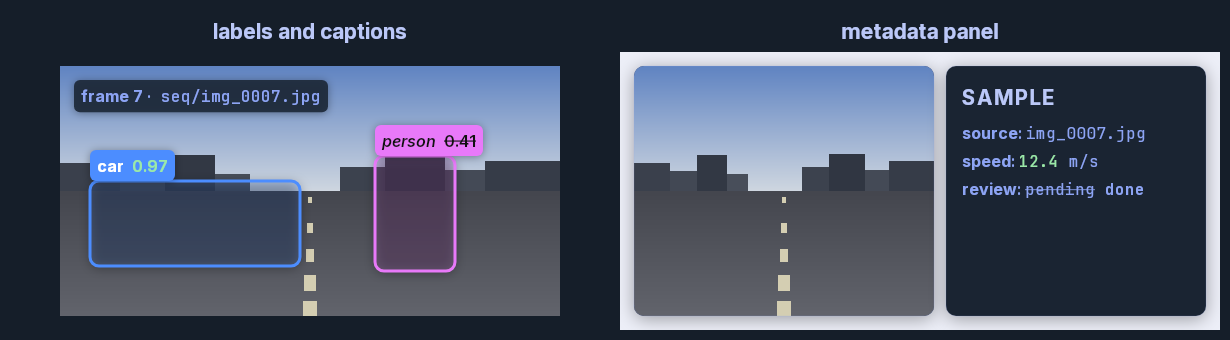

In [30]:
marked = (
    Image(street(500, 250))
    .add(BBox(x=0.06, y=0.46, w=0.42, h=0.34,
              label="<b>car</b>  <span color='#9be9a8'>0.97</span>", color="#4c8dff"))
    .add(BBox(x=0.63, y=0.36, w=0.16, h=0.46,
              label="<i>person</i>  <s>0.41</s>", color="#e879f9"))
    .add(Caption(text="<b>frame 7</b>  ·  <code>seq/img_0007.jpg</code>",
                 corner=Corner.TOP_LEFT))
)

panelled = Image(street(300, 250)).with_panel(
    {
        "<b>source</b>": "<code>img_0007.jpg</code>",
        "<b>speed</b>": "<span color='#9be9a8'>12.4</span> m/s",
        "<b>review</b>": "<s>pending</s>  <b>done</b>",
    },
    title="<b>sample</b>",
)

grid([marked, panelled], ncols=2, titles=["labels and captions", "metadata panel"])

<a id="5"></a>
# 5. Composition

Every composition function returns a **new** scene and leaves its inputs alone,
so the same `Image` can appear in several figures.

- `blend` — two frames over each other (what a MixUp augmentation looks like);
- `hstack` / `vstack` / `grid` — you choose the shape;
- `combine` — it chooses the shape;
- `with_panel` — a metadata sidebar that never covers the pixels.

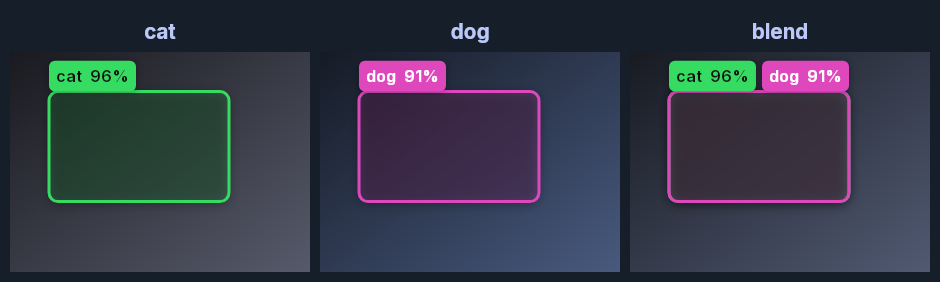

In [31]:
cat = Image(ramp(300, 220, hue=0.58)).add(
    BBox(x=0.13, y=0.18, w=0.6, h=0.5, label="cat", score=0.96))
dog = Image(ramp(300, 220, hue=0.08)).add(
    BBox(x=0.13, y=0.18, w=0.6, h=0.5, label="dog", score=0.91))

hstack([cat, dog, blend(cat, dog, alpha=0.4)], titles=["cat", "dog", "blend"])

## 5.1 `combine` — layout-free composition

Where `grid` asks for a column count, `combine` takes a mix of finished images
and image *groups* and arranges them itself. Each positional argument is one
group, and it accepts three kinds: a titled mapping `{title: image}`, a bare
list (which becomes its own reflowing sub-grid), and a single image placed
as-is.

The point is that changing the class list below reshapes the whole figure
without touching any layout code — which is what you want when the number of
classes is a property of the model, not of the notebook.

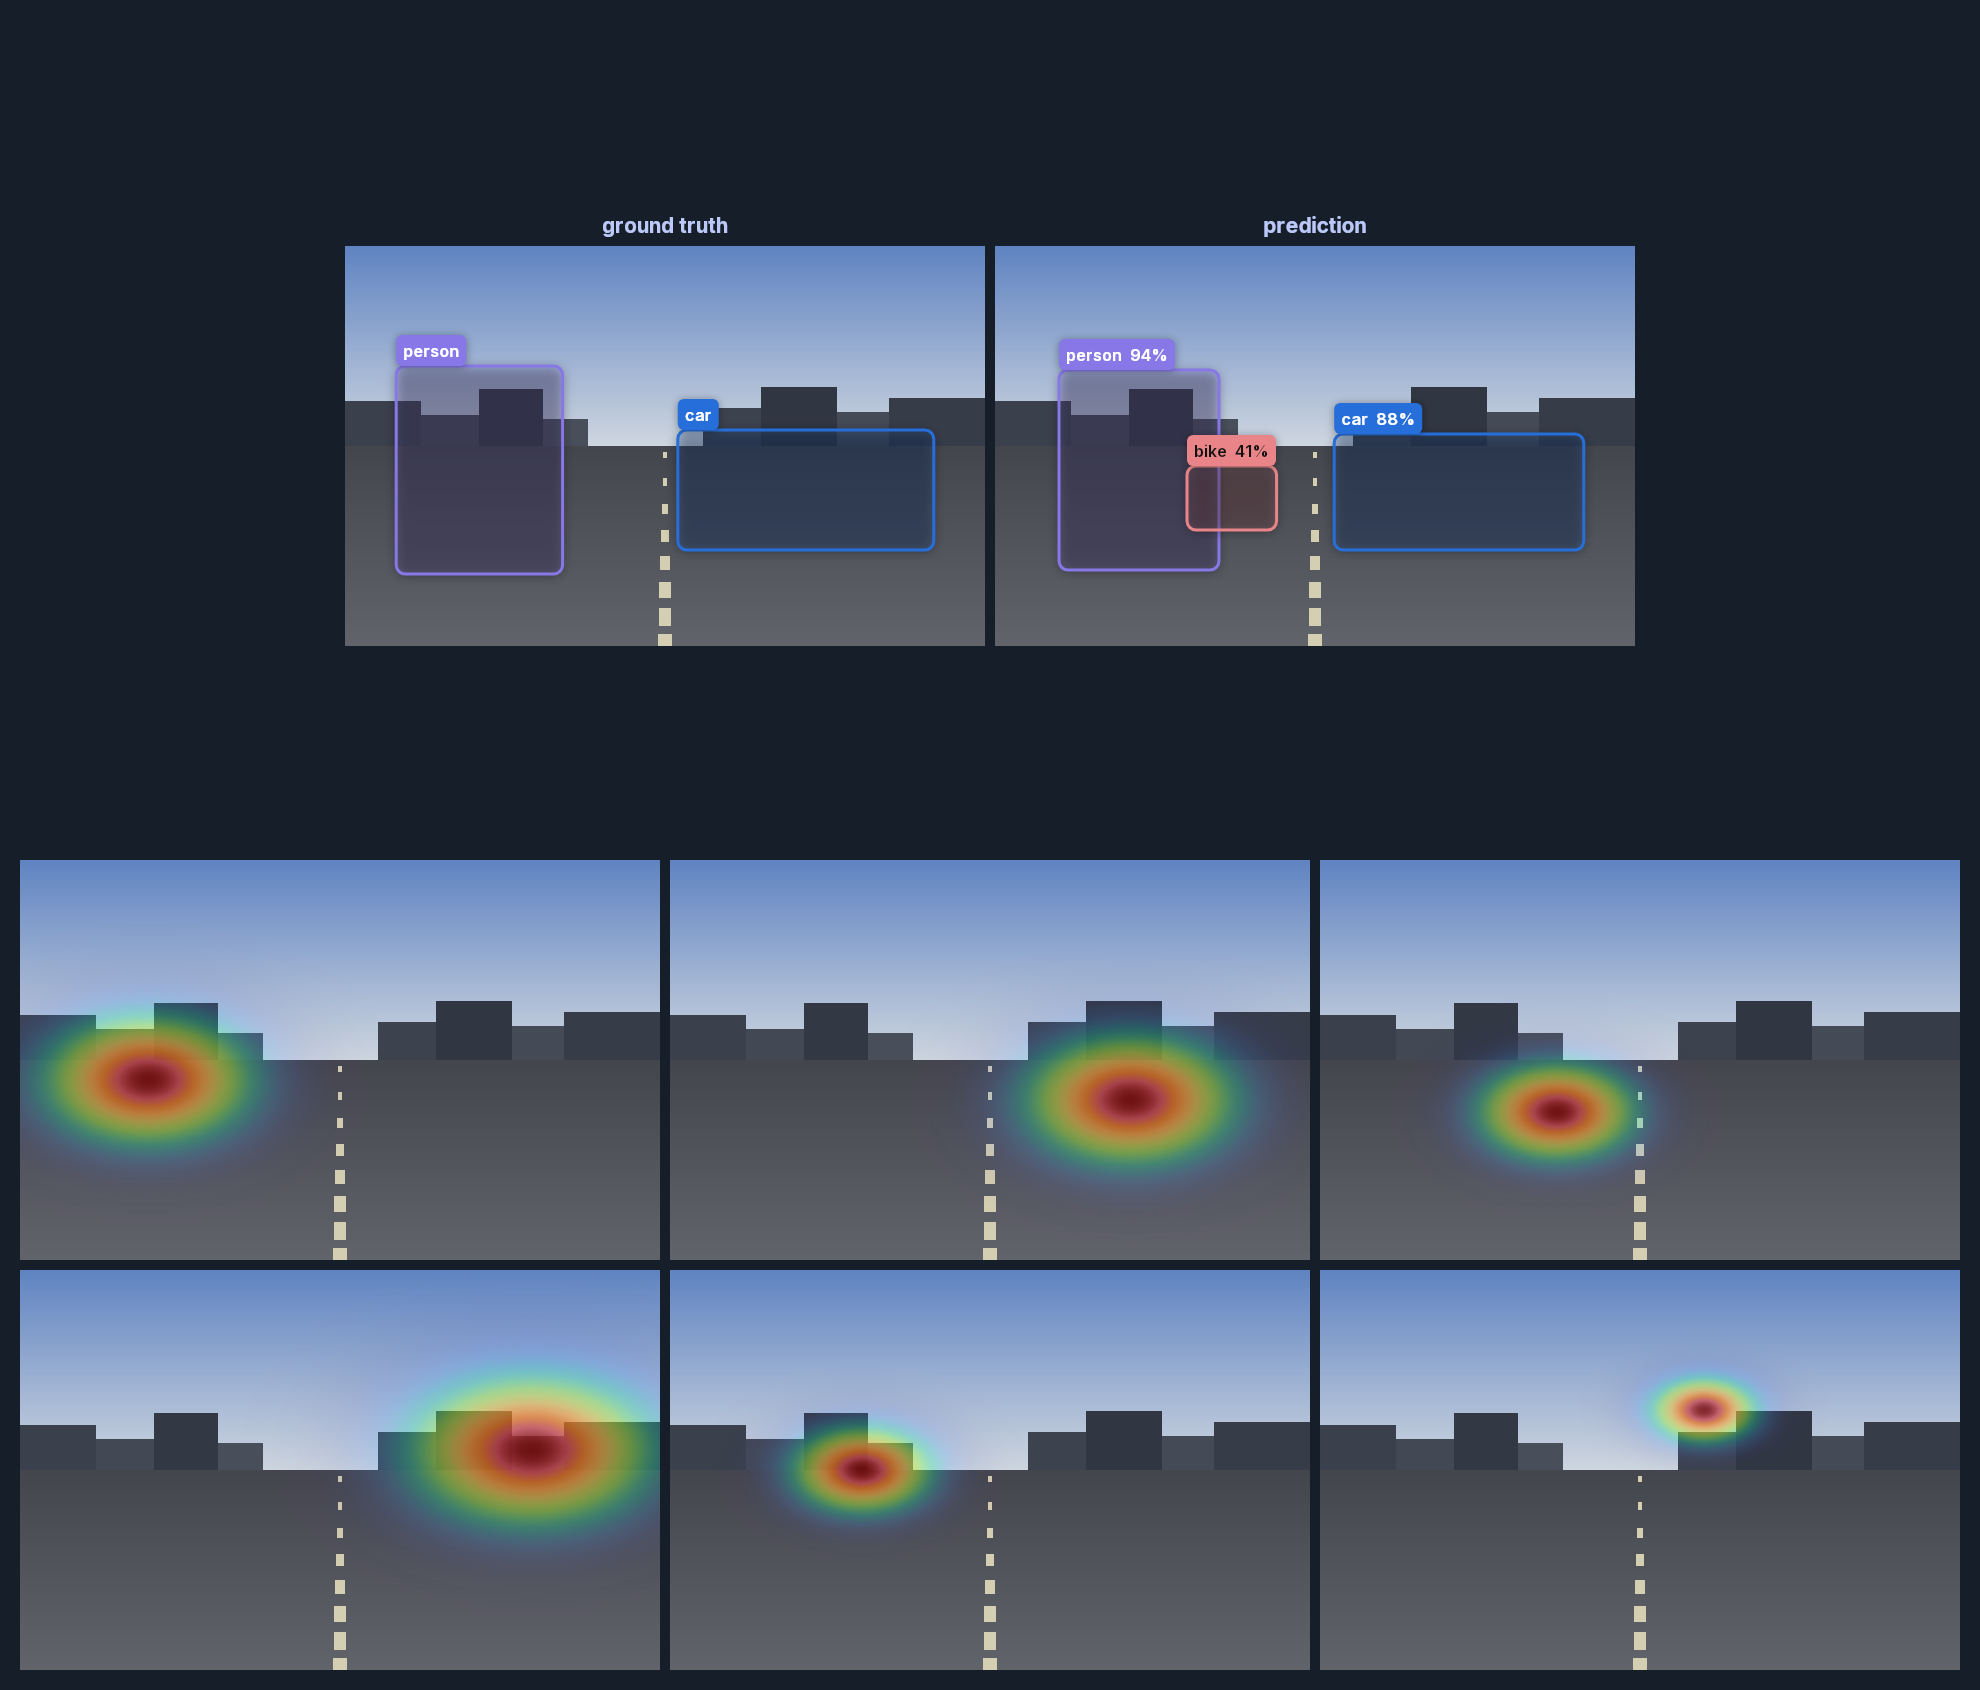

In [32]:
truth = (
    Image(SCENE)
    .add(BBox(x=0.08, y=0.30, w=0.26, h=0.52, label="person"))
    .add(BBox(x=0.52, y=0.46, w=0.40, h=0.30, label="car"))
)
guess = (
    Image(SCENE)
    .add(BBox(x=0.10, y=0.31, w=0.25, h=0.50, label="person", score=0.94))
    .add(BBox(x=0.53, y=0.47, w=0.39, h=0.29, label="car", score=0.88))
    .add(BBox(x=0.30, y=0.55, w=0.14, h=0.16, label="bike", score=0.41))
)

per_class = {
    "person": [(0.20, 0.55, 0.12)], "car": [(0.72, 0.60, 0.12)],
    "bike": [(0.37, 0.63, 0.09)], "truck": [(0.80, 0.45, 0.14)],
    "rider": [(0.30, 0.50, 0.08)], "sign": [(0.60, 0.35, 0.06)],
}
maps = [
    Image(SCENE).add(Heatmap(values=blobs(SCENE.shape[1], SCENE.shape[0], centres)))
    for centres in per_class.values()
]

combine({"ground truth": truth, "prediction": guess}, maps)

## 5.2 The side panel

`with_panel` appends a sidebar rather than drawing over the frame, so metadata
never occludes the labels it describes. It renders nested dicts and lists as a
tree, and it is what `visualize_record` uses for `sample_metadata`.

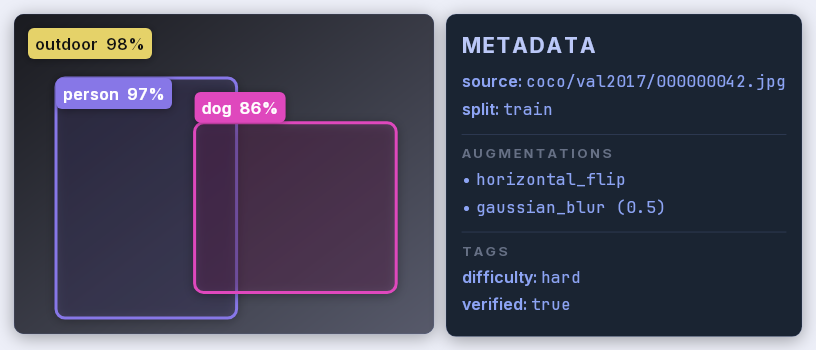

In [33]:
(
    Image(ramp(420, 320, hue=0.58))
    .add(BBox(x=0.1, y=0.2, w=0.43, h=0.75, label="person", score=0.97))
    .add(BBox(x=0.43, y=0.34, w=0.48, h=0.53, label="dog", score=0.86))
    .add(Classification(tags=[("outdoor", 0.98)]))
    .with_panel(
        {
            "source": "coco/val2017/000000042.jpg",
            "split": "train",
            "augmentations": ["horizontal_flip", "gaussian_blur (0.5)"],
            "tags": {"difficulty": "hard", "verified": True},
        },
        title="metadata",
    )
)

<a id="6"></a>
# 6. Comparing predictions against the truth

`compare` matches predictions to ground truth (COCO-style: greedy by
confidence, class-aware, at IoU 0.5) and colours **by outcome** rather than by
class:

- **green** — a true positive. The faint dashed ghost behind it is where the
  truth actually was, so localisation drift stays visible.
- **red** — a false positive: a prediction with nothing under it.
- **dashed amber** — a false negative: truth the model missed.
- **orange** — a class error: right box, wrong label, chip `gt → pred`. It
  scores as a false positive *plus* a false negative; the separate colour just
  makes the mistake easy to spot.

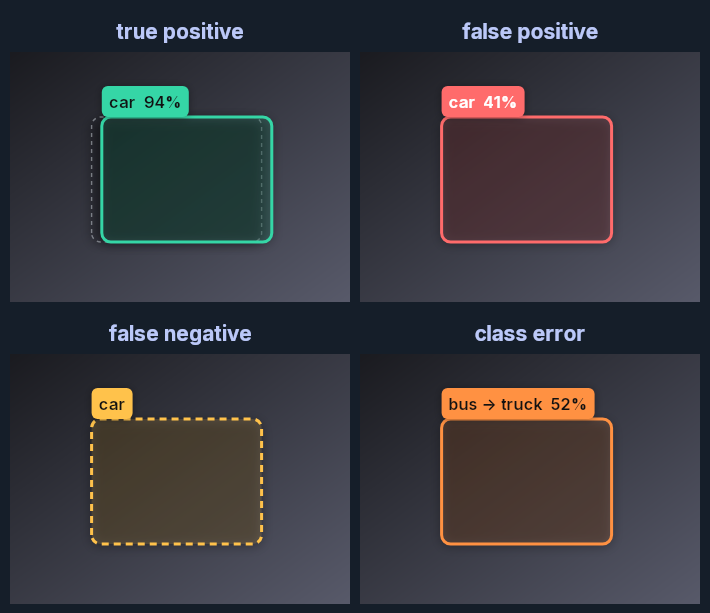

In [34]:
key_gt = [BBox(x=0.24, y=0.26, w=0.5, h=0.5, label="car")]
verdicts = {
    "true positive": (key_gt, [BBox(x=0.27, y=0.26, w=0.5, h=0.5, label="car", score=0.94)]),
    "false positive": ([], [BBox(x=0.24, y=0.26, w=0.5, h=0.5, label="car", score=0.41)]),
    "false negative": (key_gt, []),
    "class error": ([BBox(x=0.24, y=0.26, w=0.5, h=0.5, label="bus")],
                    [BBox(x=0.24, y=0.26, w=0.5, h=0.5, label="truck", score=0.52)]),
}
grid(
    [compare(ramp(hue=0.6), gt=gt, pred=pred, panel=False)
     for gt, pred in verdicts.values()],
    ncols=2,
    titles=list(verdicts),
)

## 6.1 The three layouts

`show` picks how the comparison is laid out. **overlay** puts everything on one
frame coloured by verdict, with the aggregate report — precision, recall, F1,
mean IoU, counts, and with `per_class=True` a per-class breakdown — in the
panel. **side_by_side** keys colour to *identity* instead: a matched pair shares
a hue across the two panels, so the errors are the boxes with no twin.
**triptych** adds a dedicated diff panel.

Every box also carries a hover `Tooltip` explaining its verdict — invisible in a
static figure, live in §7's HTML export and §8's viewer.

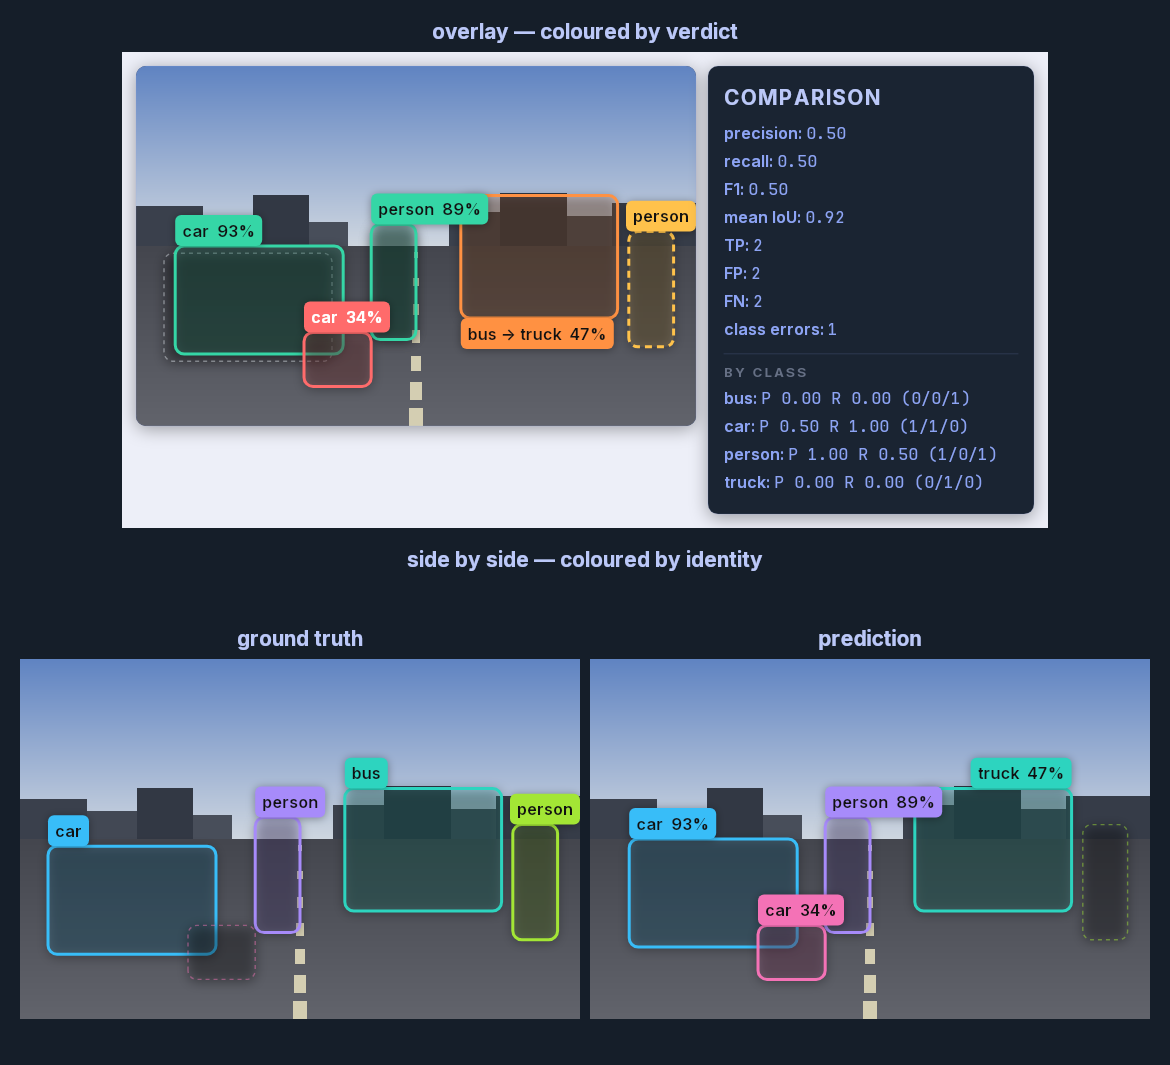

In [35]:
gt = [
    BBox(x=0.05, y=0.52, w=0.30, h=0.30, label="car"),
    BBox(x=0.42, y=0.44, w=0.08, h=0.32, label="person"),
    BBox(x=0.58, y=0.36, w=0.28, h=0.34, label="bus"),
    BBox(x=0.88, y=0.46, w=0.08, h=0.32, label="person"),   # missed
]
pred = [
    BBox(x=0.07, y=0.50, w=0.30, h=0.30, label="car", score=0.93),   # nudged: TP + ghost
    BBox(x=0.42, y=0.44, w=0.08, h=0.32, label="person", score=0.89),
    BBox(x=0.58, y=0.36, w=0.28, h=0.34, label="truck", score=0.47),  # class error
    BBox(x=0.30, y=0.74, w=0.12, h=0.15, label="car", score=0.34),    # false positive
]
frame = street(560, 360)

vstack(
    [
        compare(frame, gt=gt, pred=pred, per_class=True),
        compare(frame, gt=gt, pred=pred, show="side_by_side", panel=False),
    ],
    titles=["overlay — coloured by verdict", "side by side — coloured by identity"],
)

## 6.2 Whole detection trees

`compare` takes LDF `Detection` objects too, not just boxes, and every part of a
detection inherits its verdict colour — so a mask predicted with the wrong label
turns orange along with its box. Shown as the `triptych` layout.

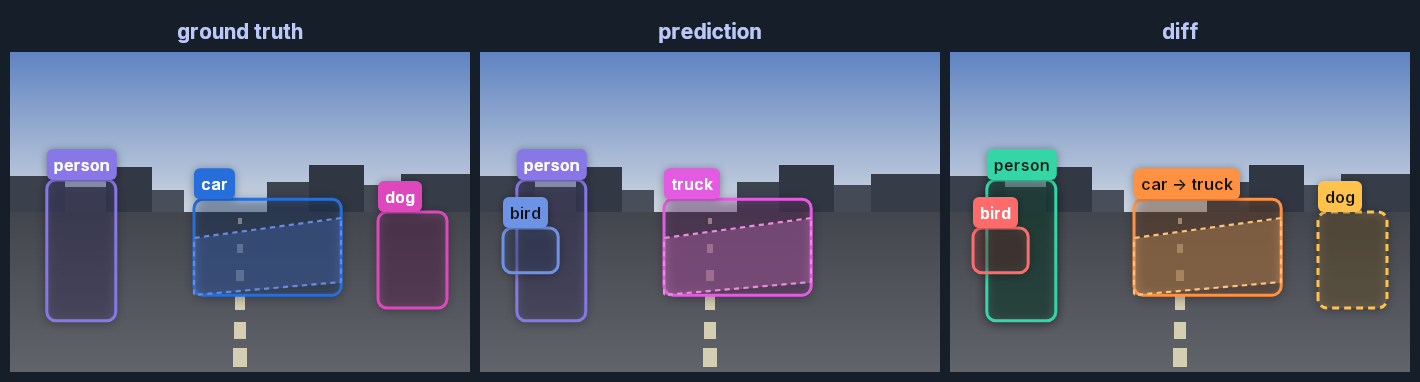

In [36]:
tw, th = 460, 320
car_box = {"x": 0.4, "y": 0.46, "w": 0.32, "h": 0.3}
car_mask = {"height": th, "width": tw,
            "points": [(0.4, 0.58), (0.72, 0.52), (0.72, 0.72), (0.4, 0.76)]}
person_box = {"x": 0.08, "y": 0.4, "w": 0.15, "h": 0.44}


def det(**data):
    return Detection.model_validate(data)


compare(
    street(tw, th),
    gt=[
        det(class_name="person", boundingbox=person_box),
        det(class_name="car", boundingbox=car_box, instance_segmentation=car_mask),
        det(class_name="dog", boundingbox={"x": 0.8, "y": 0.5, "w": 0.15, "h": 0.3}),
    ],
    pred=[
        det(class_name="person", boundingbox=person_box),                     # TP
        det(class_name="truck", boundingbox=car_box,                          # class error
            instance_segmentation=car_mask),
        det(class_name="bird",                                                # false positive
            boundingbox={"x": 0.05, "y": 0.55, "w": 0.12, "h": 0.14}),
    ],
    show="triptych",
    panel=False,
)

## 6.3 Keypoints, graded per joint

When a matched detection carries keypoints, each joint is scored on its own —
green within tolerance, red when off — instead of the whole pose taking one
colour. A limb between two differently graded joints fades between them.

Left to right: no box match at all (so no per-joint grading is possible), a box
match with some joints misplaced, and a clean match.

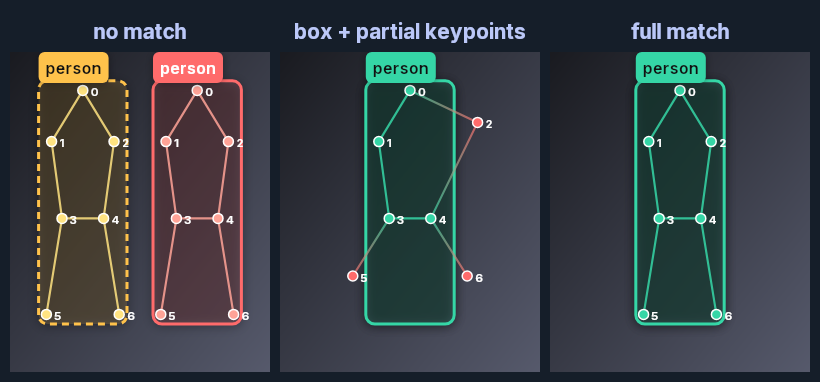

In [37]:
BASE = [(0.5, 0.12, 2), (0.38, 0.28, 2), (0.62, 0.28, 2), (0.42, 0.52, 2),
        (0.58, 0.52, 2), (0.36, 0.82, 2), (0.64, 0.82, 2)]
LIMBS = [(0, 1), (0, 2), (1, 3), (2, 4), (3, 4), (3, 5), (4, 6)]
kp_options = RenderOptions(draw_skeletons=True, skeletons={"": ([], LIMBS)})


def bounds(joints):
    xs = [x for x, _, _ in joints]
    ys = [y for _, y, _ in joints]
    return {"x": min(xs) - 0.03, "y": min(ys) - 0.03,
            "w": max(xs) - min(xs) + 0.06, "h": max(ys) - min(ys) + 0.06}


def person(joints, box=None):
    return Detection.model_validate({
        "class_name": "person",
        "boundingbox": box or bounds(joints),
        "keypoints": {"keypoints": joints},
    })


partial = list(BASE)
partial[2] = (0.76, 0.22, 2)   # right shoulder, badly placed
partial[5] = (0.28, 0.70, 2)   # both feet, short
partial[6] = (0.72, 0.70, 2)
left = [(x - 0.22, y, v) for x, y, v in BASE]
right = [(x + 0.22, y, v) for x, y, v in BASE]
backdrop = ramp(260, 320, hue=0.55)

grid(
    [
        compare(backdrop, gt=[person(left)], pred=[person(right)],
                options=kp_options, panel=False),
        compare(backdrop, gt=[person(BASE)], pred=[person(partial, bounds(BASE))],
                options=kp_options, panel=False),
        compare(backdrop, gt=[person(BASE)], pred=[person(BASE)],
                options=kp_options, panel=False),
    ],
    ncols=3,
    titles=["no match", "box + partial keypoints", "full match"],
)

## 6.4 Across a whole dataset

`match_detections` returns the raw result for one image; feed a run of them into
a `ComparisonReport` and `confusion_matrix_figure` gives the classic
model-debugging view. Rows are the truth, columns the prediction, with a
trailing `∅` for misses and false alarms — the column that tells you whether the
model is confusing classes or simply not seeing them.

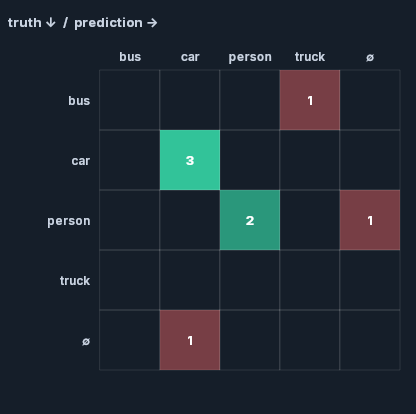

In [38]:
def box(x, y, label, score=None):
    return BBox(x=x, y=y, w=0.22, h=0.22, label=label, score=score)


images = [
    ([box(0.10, 0.10, "car"), box(0.55, 0.10, "person")],
     [box(0.10, 0.10, "car", 0.9), box(0.55, 0.10, "person", 0.8)]),
    ([box(0.10, 0.55, "bus"), box(0.55, 0.55, "car")],
     [box(0.10, 0.55, "truck", 0.5), box(0.55, 0.55, "car", 0.85)]),
    ([box(0.10, 0.10, "person"), box(0.55, 0.60, "person")],
     [box(0.10, 0.10, "person", 0.7)]),                    # one person missed
    ([box(0.30, 0.30, "car")],
     [box(0.30, 0.30, "car", 0.9), box(0.72, 0.72, "car", 0.4)]),   # a false alarm
]

report = ComparisonReport()
for truth_boxes, predicted in images:
    report.add(match_detections(truth_boxes, predicted))

confusion_matrix_figure(report)

<a id="7"></a>
# 7. Getting it out

`save` picks the encoder from the extension: `.png` / `.jpg` / `.webp` raster,
`.svg` vector, `.html` a self-contained interactive page. `save_video` does the
same for a whole sequence.

In [39]:
scene = (
    Image(street(480, 300))
    .add(BBox(x=0.08, y=0.5, w=0.3, h=0.28, label="car", score=0.94,
              tooltip=Tooltip(title="car #1",
                              rows=(("speed", "48 km/h"), ("lane", "2")))))
    .add(BBox(x=0.62, y=0.42, w=0.1, h=0.34, label="person", score=0.88,
              tooltip=Tooltip(title="person #7", rows=(("pose", "walking"),))))
    .add(Caption(text="frame_0007.jpg", corner=Corner.TOP_LEFT))
)

for name in ["scene.png", "scene.jpg", "scene.webp", "scene.svg", "scene.html"]:
    path = scene.save(scratch / name)
for path in sorted(scratch.glob("scene.*")):
    print(f"{path.name:<12} {path.stat().st_size / 1024:7.1f} KiB")

scene.html     102.4 KiB
scene.jpg       19.6 KiB
scene.png       18.2 KiB
scene.svg       95.4 KiB
scene.webp       7.9 KiB


## 7.1 The interactive HTML export

`render_html` welds the vector render and the hover regions into **one
self-contained page**: markup, styling, script, and fonts all inline, no
external request, no companion files. The tooltips work, and the checkboxes
switch layers and classes off through CSS alone — which means it keeps working
through composites (grids, panelled scenes) whose children a caller cannot
reach.

It embeds straight into this notebook, below. **Hover a box**, and try the
checkboxes. (This needs a live Jupyter or VS Code session — GitHub's notebook
viewer strips embedded HTML, so there it will look blank. `scene.save("s.html")`
writes the same page as a file you can open in any browser.)

102 KiB, self-contained — no external request



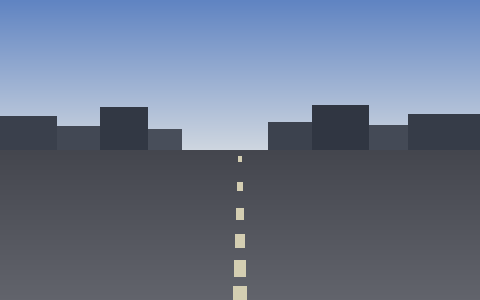

In [40]:
import html
import warnings

from IPython.display import HTML

page = scene.render_html(title="vizlab")
print(f"{len(page) / 1024:.0f} KiB, self-contained — no external request")

with warnings.catch_warnings():
    # IPython nudges toward IFrame(src=…), but srcdoc is exactly the point:
    # the page is embedded here, not fetched from anywhere.
    warnings.simplefilter("ignore", UserWarning)
    embedded = HTML(
        f'<iframe srcdoc="{html.escape(page, quote=True)}" '
        'style="width:100%;height:440px;border:0;border-radius:8px"></iframe>'
    )
embedded

## 7.2 Video and animation

`save_video` (and `VideoWriter`, its incremental form) take the same scenes
`save` takes. The extension picks the format: `.mp4` / `.webm` / `.avi` / `.mkv`
for video, `.gif` / `.webp` / `.apng` / `.avif` for an animated image that
embeds anywhere a picture does. Frames that disagree on size are fitted rather
than stretched.

/tmp/vizlab_notebook_kpex1o2j/motion.webp — 41.8 KiB


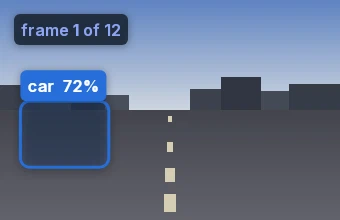

In [ ]:
frames = []
for step in range(12):
    t = step / 11.0
    moving = Image(street(340, 220))
    moving.add(BBox(x=0.06 + 0.55 * t, y=0.46 - 0.06 * t,
                    w=0.26 - 0.08 * t, h=0.3 - 0.09 * t,
                    label="car", score=0.72 + 0.2 * t))
    moving.add(Caption(text=f"frame <b>{step + 1}</b> of 12"))
    frames.append(moving)

clip = save_video(frames, scratch / "motion.webp", fps=6)
print(f"{clip} — {clip.stat().st_size / 1024:.1f} KiB")

from IPython.display import Image as IPyImage

IPyImage(filename=str(clip))

<a id="8"></a>
# 8. The interactive viewer, in this notebook

The same `Viewer` that powers `luxonis_ml data inspect` — there over an OpenCV
window — drives an `ipywidgets` surface here. Page with **◀ Prev / Next ▶**,
hover a box for its metadata card, and click the panel to change what is drawn:

- the **CONTROLS** rows toggle masks / keypoints / boxes / labels / declutter,
- a **class swatch** hides or shows that one class, and **HIDE ALL / SHOW ALL**
  (beside the CLASSES heading) flips every class at once.

Needs the `notebook` extra — `ipywidgets` plus `ipyevents`, the latter being
what carries both hover and clicks.

In [ ]:
from luxonis_ml.vizlab import Controls, Frame, Swatches
from luxonis_ml.vizlab.viewer import NotebookBackend, Viewer


def street_sample():
    """A car and a walking person, both with hover metadata."""
    img = Image(street(420, 280))
    img.add(BBox(x=0.08, y=0.48, w=0.3, h=0.3, label="car", score=0.94,
                 tooltip=Tooltip(title="car #1",
                                 rows=(("speed", "48 km/h"), ("lane", "2")))))
    img.add(
        BBox(x=0.62, y=0.4, w=0.1, h=0.36, label="person", score=0.88,
             tooltip=Tooltip(title="person #7", rows=(("pose", "walking"),)))
        .add(Keypoints(keypoints=[(0.67, 0.46, 2), (0.67, 0.6, 2), (0.66, 0.72, 2)]))
    )
    return img


def pets_sample():
    """A dog and a cat, to show a class set changing between samples."""
    img = Image(ramp(420, 280, hue=0.3))
    img.add(BBox(x=0.12, y=0.22, w=0.4, h=0.55, label="dog", score=0.9,
                 tooltip=Tooltip(title="dog #3", rows=(("breed", "corgi"),))))
    img.add(BBox(x=0.58, y=0.16, w=0.3, h=0.46, label="cat", score=0.86,
                 tooltip=Tooltip(title="cat #4", rows=(("colour", "tabby"),))))
    return img


samples = [
    {"classes": ("car", "person"),
     "meta": {"filename": "street_0012.jpg", "split": "val", "weather": "clear"},
     "build": street_sample},
    {"classes": ("dog", "cat"),
     "meta": {"filename": "pets_0007.jpg", "split": "train"},
     "build": pets_sample},
]

# One palette over every class in the set, so a colour means the same thing on
# every sample — the same guarantee a dataset palette gives.
viewer_palette = Palette(sorted({c for s in samples for c in s["classes"]}))

`build_frame` is the whole integration: it rebuilds the current sample for
whatever the layer toggles currently say (`viewer.layers.apply_layers`) and
attaches the panel with `Frame.with_panel`. Passing it as the `render` callback
is what makes the panel live — every click re-renders through it. `hud=False`
keeps the controls in the panel instead of floating them over the image.

`run()` returns immediately; the notebook's own event loop keeps the viewer
alive.

In [ ]:
viewer = Viewer(NotebookBackend(), hud=False)
state = {"i": 0}


def sidebar():
    """CONTROLS + the CLASSES legend + this sample's metadata."""
    panel = {
        "controls": Controls(
            tuple((c.key, c.name, c.value, c.active)
                  for c in viewer.layers.controls())
        )
    }
    if viewer.layers.classes:
        panel["classes"] = Swatches(
            tuple((viewer_palette.color_for(name), name)
                  for name in viewer.layers.classes),
            disabled=frozenset(viewer.layers.hidden),
        )
    panel.update(samples[state["i"]]["meta"])
    return panel


def build_frame(layers) -> Frame:
    """(Re)build the framed scene for the current toggles and panel state."""
    img = samples[state["i"]]["build"]()
    img.annotations[:] = layers.apply_layers(img.annotations, viewer_palette)
    return img.frame().with_panel(sidebar(), title="Sample metadata")


def show():
    viewer.layers.update_classes(samples[state["i"]]["classes"])
    viewer.show("viewer", build_frame(viewer.layers), render=build_frame)


def on_key(char: str) -> None:
    if char == "q":
        viewer.close()
    elif char in ("n", "p"):
        state["i"] = (state["i"] + (1 if char == "n" else -1)) % len(samples)
        show()


show()
viewer.run(on_key)

## Where to go next

- **`luxonis_ml data inspect <dataset>`** — this viewer over a real dataset,
  with filters, augmentation previews, and `--save` to PNG/HTML/video.
- **`vizlab_examples/gallery.py`** — the same figures rendered to
  `vizlab_examples/output/` for the docs; run it to regenerate them.
- **`vizlab_examples/showcase_scene.py`** — one dense scene in a desktop window,
  handy as a smoke test while developing.
- **`vizlab_examples/camera_3d/`** — projecting 3-D geometry, depth, and point
  clouds into a camera.
- **`help(luxonis_ml.vizlab)`** — the module docstring is the API map.

In [ ]:
import shutil

shutil.rmtree(scratch, ignore_errors=True)
if dataset is not None:
    dataset.delete_dataset(delete_local=True)
print("cleaned up")

cleaned up
